# Cloud layers: Vertical structures in Tropics
This Notebook will
+ read HALO radar data
+ categorize clouds due vertical structure: 5 masks for high level, upperlevel, midlevel, lowlevel clouds as well as rain
+ apply categorizing algorithm on radar data
+ provide a visualization of masks
+ combine data with IWV, IWP, LWP data

Preverred env: orcestra-retrieval-env

## Load packages

In [1]:
#%% Loading packages
import numpy as np
import datetime as dt
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import fsspec
from matplotlib import cm
from matplotlib.colors import Normalize 
import matplotlib.dates as mdates
from scipy.interpolate import interpn
import glob
from functools import partial
import sys
#sys.path.append('/home/u/u301238/master_thesis/')
sys.path.append('/home/u/u301032/orcestra/NN_IWP_retrieval/')
import seaborn as sns
#import src
import src_comparison_halo_pamtra as chp
from scipy.ndimage import uniform_filter1d
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker


## Read Data


In [2]:


#ds_radar=xr.open_dataset('/work/um0203/u301032/master_thesis/flight_data/radar_with_mask_and_CTH.nc')#,parallel=True)
#ds_radar=xr.open_dataset('/work/um0203/u301032/master_thesis/flight_data/radar_with_mask_and_CTH_adjusted_shallow_convection2.nc')
#ds_radar=xr.open_dataset('/work/um0203/u301032/master_thesis/flight_data/radar_with_mask_and_CTH_and_CBH_adjusted_shallow_convection3.nc')
ds_radar=xr.open_dataset('/work/um0203/u301032/master_thesis/flight_data/radar_convection.nc')
#ds_hamp=xr.open_dataset('/work/um0203/u301032/master_thesis/retrieved_data/HAMP_with_IWV_IWP_LWP_v2_with_mask.nc')
ds_hamp=xr.open_dataset('/work/um0203/u301032/master_thesis/retrieved_data/HAMP_with_IWV_IWP_LWP_TLWP_v2.nc')

In [3]:
categories = ["high", "upper", "mid", "low", "rain"]
upper_limits = [15060, 8000, 5000, 2200, 700] #davor 1500 bis 2000 für low clouds #davor 1600 bis 2200 für low clouds
lower_limits = [8000, 5000, 2200, 1500, 500]

#categories = [ "mid", "low", "rain_or_low" ,"rain"]
#upper_limits = [5000, 2000, 1500 ,700] #davor 1500 bis 2000 für low clouds
#lower_limits = [2000, 1500, 700 ,500]
def percentile(n):
    def percentile_(x):
        return x.quantile(n)
    percentile_.__name__ = 'percentile_{:02.0f}'.format(n*100)
    return percentile_

agg_list=["count", "mean", "min",percentile(0.25), "median",percentile(0.75), "max",  "skew"]

## Categorizing algorithm on radar data

 creates masks for cloud levels and identifies cloud top height

In [5]:


def create_radar_masks(ds_radar, categories, upper_limits, lower_limits):
    for category, upper_limit, lower_limit in zip(categories, upper_limits, lower_limits):
        if category == "rain":  # rain needs different naming conventions
            variable_name = f"mask_{category}"
            long_name = f"{category}"
        else:
            variable_name = f"mask_{category}_level_cloud"
            long_name = f"{category} level clouds"
        # Create mask based on Zg within specified height slice
        ds_radar[variable_name] = ds_radar.Zg.sel(height=slice(lower_limit, upper_limit)).notnull().any(dim='height')
        # Add attributes
        ds_radar[variable_name].attrs['description'] = (
            f'1 indicates the occurrence of radar reflectivity within {upper_limit} m to {lower_limit} m, 0 indicates no signal'
        )
        ds_radar[variable_name].attrs['long_name'] = f'Mask for detection of {long_name}'
    return ds_radar

def adjust_radar_masks(ds_radar, categories, upper_limits, lower_limits):
    for category, upper_limit, lower_limit in zip(categories, upper_limits, lower_limits):
        if category == "rain":  # rain needs different naming conventions
            variable_name = f"mask_{category}"
            long_name = f"{category}"
        else:
            variable_name = f"mask_{category}_level_cloud"
            long_name = f"{category} level clouds"
        # Create mask based on Zg within specified height slice
        ds_radar[variable_name] = ds_radar.Zg.sel(height=slice(lower_limit, upper_limit)).notnull().any(dim='height')
        if category == "rain_or_low":
            # Add attributes
            ds_radar[variable_name].attrs['description'] = (
                f'1 indicates the occurrence of radar reflectivity within {upper_limit} m to {lower_limit} m, 0 indicates no signal'
            )
            ds_radar[variable_name].attrs['long_name'] = f'Mask for detection of {long_name}'
    return ds_radar

In [94]:
def get_CTH(da,exlude_below=500):
    da_zeros=xr.zeros_like(da)
    da_h=xr.DataArray(da.coords['height'].values,dims='height',coords={'height':da.coords['height'].values})
    CTH=da_zeros.where(da.isnull(),other=da_h).max(dim='height')
    # Exclude heights below 500 m to exclude ocean as cloud top height
    return CTH.where(CTH > exlude_below,other=np.nan)

def get_CBH(da,exlude_below=1500):
    da_zeros=xr.zeros_like(da)
    da_h=xr.DataArray(da.coords['height'].values,dims='height',coords={'height':da.coords['height'].values})
    CTH=da_zeros.where(da.isnull(),other=da_h).min(dim='height')
    # Exclude heights below 500 m to exclude ocean as cloud top height
    return CTH.where(CTH > exlude_below,other=np.nan)

def create_convection_mask(ds_radar, categories, lower_limits):
    for category, upper_limit, lower_limit in zip(categories, upper_limits, lower_limits):
        variable_name = "convection_height"
        long_name = f"convection height"
        
        ds_radar[variable_name] = ds_radar.Zg.sel(height=slice(lower_limit, ds_radar.CTH)).notnull().any(dim='height')
        # Add attributes
        ds_radar[variable_name].attrs['description'] = (
            f'1 indicates the occurrence of radar reflectivity within {upper_limit} m to {lower_limit} m, 0 indicates no signal'
        )
        ds_radar[variable_name].attrs['long_name'] = f'Mask for detection of {long_name}'
    return ds_radar

In [6]:
%%time
#categories = [ "mid", "low"]
#upper_limits = [ 5000, 2200] #davor 1500 bis 2000 für low clouds
#lower_limits = [ 2200, 1600]
#only adjust radar variables
ds_radar = adjust_radar_masks(ds_radar, categories, upper_limits, lower_limits)#create_radar_masks(ds_radar, categories, upper_limits, lower_limits)
#cloud top height unchanged
#CTH = get_CTH(ds_radar.Zg,exlude_below=500)

#ds_radar['CTH']=CTH
#ds_radar['CTH'].attrs['long_name'] = 'Cloud top height'
#ds_radar['CTH'].attrs['description'] = 'Cloud top height in m from radar data, CTH under 500m are NaN'
#ds_radar.CTH

#ds_radar.to_netcdf('/work/um0203/u301032/master_thesis/flight_data/radar_with_mask_and_CTH_adjusted_shallow_convection2.nc')

CPU times: user 10.8 ms, sys: 27.3 ms, total: 38.1 ms
Wall time: 38.4 ms


In [17]:
ds_hamp_kw=xr.open_dataset('/work/um0203/u301032/master_thesis/flight_data/halo_iwv_kw.nc')

Text(0.5, 9.444444444444438, 'IWV /  kg m$^{-2}$')

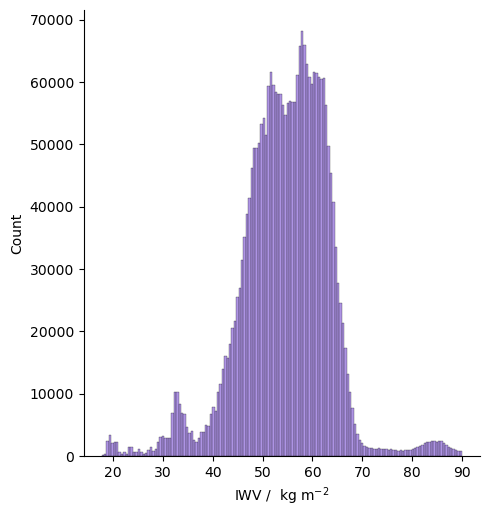

In [20]:
sns.displot(ds_hamp_kw.IWV.where(ds_hamp_kw.IWV<90),bins=150,color='mediumpurple')
plt.xlabel('IWV /  kg m$^{-2}$')

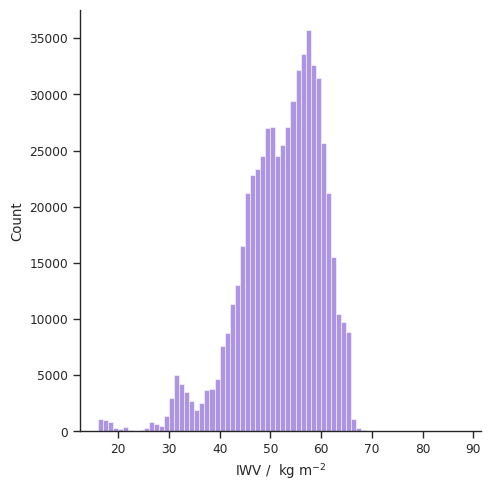

In [34]:
#fig, ax =plt.subplots()
sns.displot(ds_radar.IWV,binwidth=1,color='mediumpurple')
plt.xlabel('IWV /  kg m$^{-2}$')
#plt.figsize=(4,8)
#sns.set(font_scale=2, style='ticks')
sns.set_context("paper") #or sns.set(font_scale=2, style='ticks')
plt.tight_layout()

filename='v1'
#plt.savefig(f'/home/u/u301032/orcestra/plots/distribution_IWV_{filename}.png')

In [ ]:
thickness=ds_radar.CTH-ds_radar.CBH
#ds_radar.where(thickness<2000).plot.hist()

In [3]:
def reflectivity_percentage(ds_radar):
    # everything between 2000 m and CTH is true
    da_not_nan=ds_radar.Zg.fillna(1).where(ds_radar.height<ds_radar.CTH).where(ds_radar.height>2000)
    
    # everything below 2000 m is nan
    da_refl=ds_radar.Zg.where(ds_radar.height<ds_radar.CTH).where(ds_radar.height>2000)
    
    refl_percentage=da_refl.count(dim='height')/da_not_nan.count(dim='height')

    variable_name = f"refl_percentage"
    long_name = f"Percentage of reflectivy"

    ds_radar[variable_name] = refl_percentage
    
    # Add attributes
    ds_radar[variable_name].attrs['description'] = (
        f'percentage of True entries between 2000m and cloud top height. Entry in percentage.'
    )
    ds_radar[variable_name].attrs['long_name'] = f'Percentage of reflectivy for convective clouds'
    return ds_radar

In [4]:
ds_radar=reflectivity_percentage(ds_radar)
#ds_radar.to_netcdf('/work/um0203/u301032/master_thesis/flight_data/radar_convection.nc')

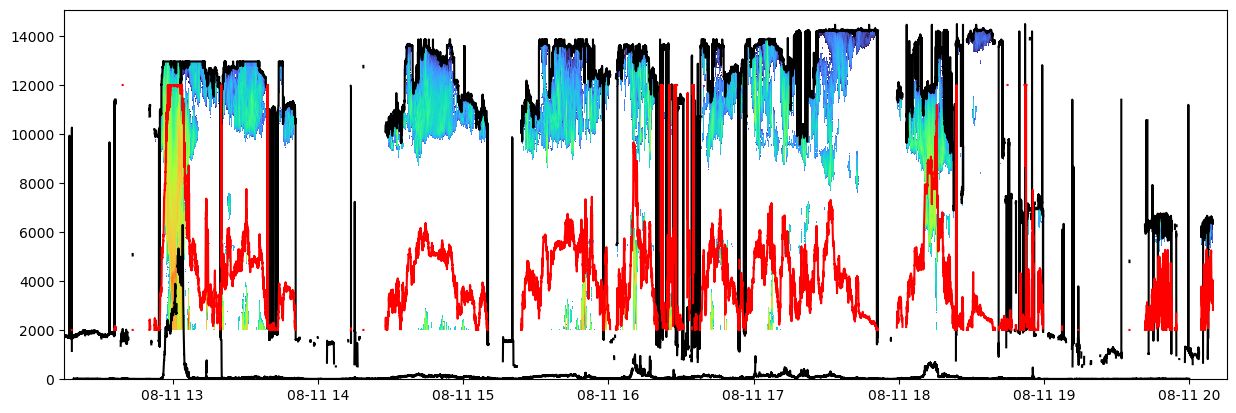

In [49]:

# everything between 2000 m and CTH is true
da_not_nan=ds_radar.Zg.fillna(1).where(ds_radar.height<ds_radar.CTH).where(ds_radar.height>2000)

# everything below 2000 m is nan
da_refl=ds_radar.Zg.where(ds_radar.height<ds_radar.CTH).where(ds_radar.height>2000)

refl_percentage=da_refl.count(dim='height')/da_not_nan.count(dim='height')

fig,axs =plt.subplots()
fig.set_figwidth(15)
im = axs.pcolormesh(
    da_not_nan.time, da_not_nan.height, 10*np.log10(da_refl.T), 
    vmin=-50, vmax=60, cmap='turbo', shading='nearest')
#axs.set_ylim(top=100)
axs.plot(da_not_nan.time,ds_radar.CTH,color='black')
axs.plot(da_not_nan.time,2000+10000*da_refl.count(dim='height')/da_not_nan.count(dim='height'),color='r')
plt.show


In [32]:
refl_percentage

<xarray.DataArray 'Zg' (time: 20907)> Size: 167kB
array([       nan,        nan,        nan, ..., 0.15172414, 0.13888889,
       0.08163265])
Coordinates:
  * time     (time) datetime64[ns] 167kB 2024-08-11T12:15:12.106914 ... 2024-...

(array([4422., 4379., 3476., 3039.,  831.,  299.,  245.,  103.,   77.,
         527.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

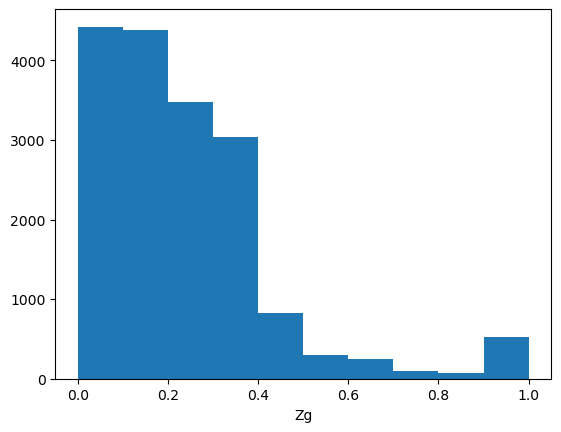

In [26]:
refl_percentage.plot.hist()

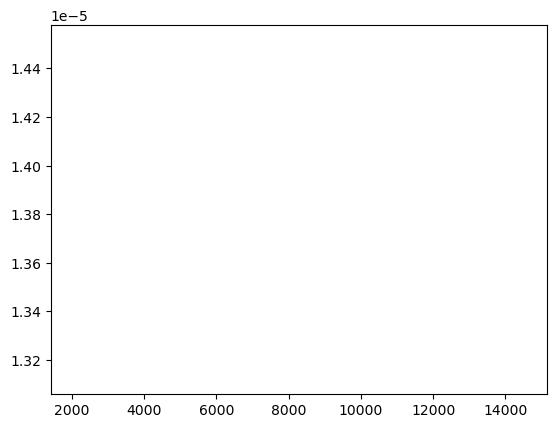

In [14]:
fig,axs =plt.subplots()
da_cth=ds_radar.CTH.where(ds_radar.refl_percentage>0.8)
da_lwp=ds_radar.LWP.where(ds_radar.refl_percentage>0.8)
color='lightsteelblue'
axs.fill_between(da_cth,da_lwp.min(),y2=da_lwp.min(),  facecolor=color, alpha=.4)
#axs.plot(da_cth,da_lwp.median(dimension='CTH'),color=color)
#axs.plot(da_cth,da_lwp.mean(),color='blue')

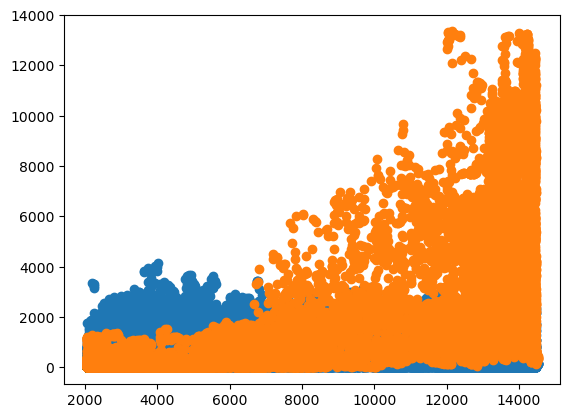

In [7]:
plt.scatter(ds_radar.CTH.where(ds_radar.refl_percentage>0.8),ds_radar.LWP.where(ds_radar.refl_percentage>0.8))

plt.scatter(ds_radar.CTH.where(ds_radar.refl_percentage>0.8),ds_radar.IWP.where(ds_radar.refl_percentage>0.8))

<Axes: xlabel='CTH', ylabel='LWP'>

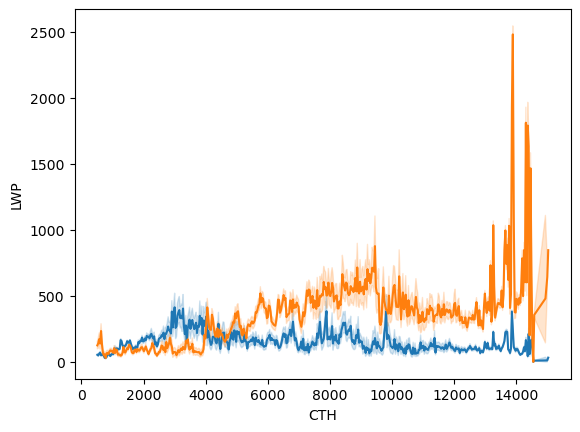

In [9]:
sns.lineplot(data=ds_radar,x="CTH", y="LWP",
         
             )
sns.lineplot(data=ds_radar,x="CTH", y="IWP",
              
             )

(array([ 8954.,  2199.,  1621.,  2315.,  1454.,   844.,   727.,   804.,
         5844., 22101.]),
 array([ 2040.,  3288.,  4536.,  5784.,  7032.,  8280.,  9528., 10776.,
        12024., 13272., 14520.]),
 <BarContainer object of 10 artists>)

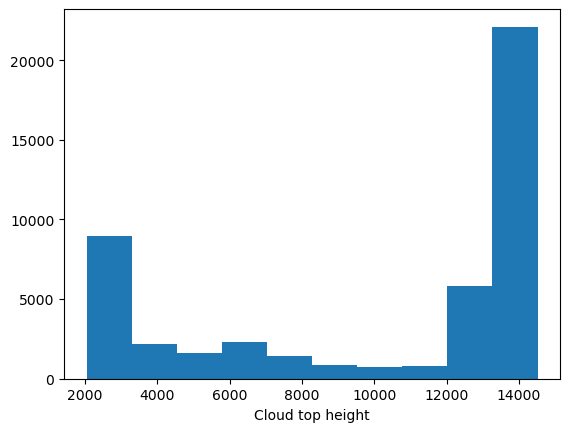

In [6]:
ds_radar.CTH.where(ds_radar.refl_percentage>0.8).plot.hist()

In [50]:

percent=ds_radar.Zg.sel(height=slice(1800,)).where(ds_radar.height<ds_radar.CTH,drop=True).count(dim='height')/ds_radar.Zg.fillna(0).sel(height=slice(1800,)).where(ds_radar.height<ds_radar.CTH,drop=True).count(dim='height')
#[height<4]#.sel(height=slice(0,da_cth))
percent


<xarray.DataArray 'Zg' (time: 396685)> Size: 3MB
array([0.35294118, 0.35294118, 0.62295082, ..., 0.39344262, 0.50819672,
       0.29508197])
Coordinates:
  * time     (time) datetime64[ns] 3MB 2024-08-09T09:52:27.624627 ... 2024-09...

In [51]:
percent[percent>0.8].count()

<xarray.DataArray 'Zg' ()> Size: 8B
array(76949)

(array([ 9935.,  6458.,  1872.,  2155.,  2773.,  1942.,  1242.,  2193.,
        10570., 37809.]),
 array([  510.,  1911.,  3312.,  4713.,  6114.,  7515.,  8916., 10317.,
        11718., 13119., 14520.]),
 <BarContainer object of 10 artists>)

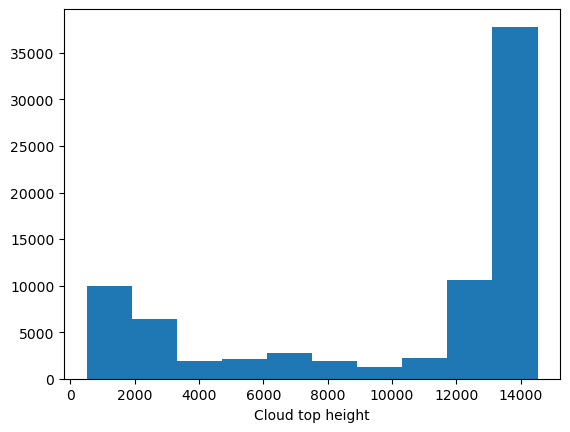

In [53]:
#ds_radar.CTH.sel(time=percent.time) #test, this should be all with CTH
convection=ds_radar.sel(time=percent[percent>0.8].time)
convection.CTH.plot.hist()

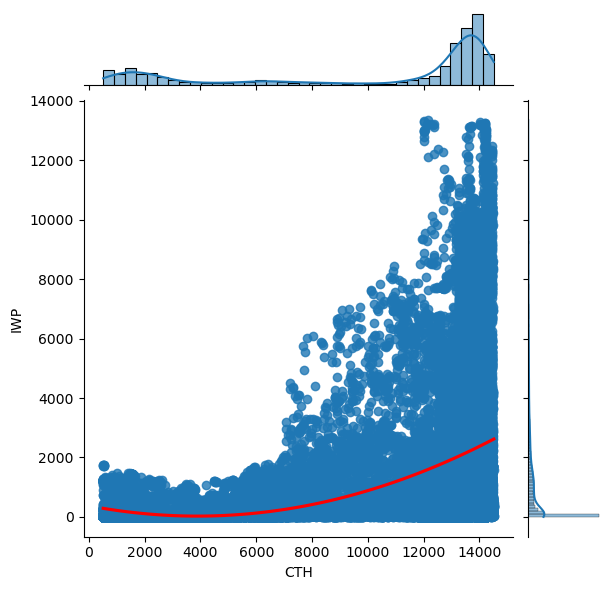

In [68]:
g = sns.jointplot(data=convection,line_kws=dict(color="r"),kind="reg",order=2,
    x="CTH", y='IWP'
)
plt.show()
#plt.scatter(convection.CTH,convection.IWP)
#plt.scatter(convection.CTH,convection.LWP)

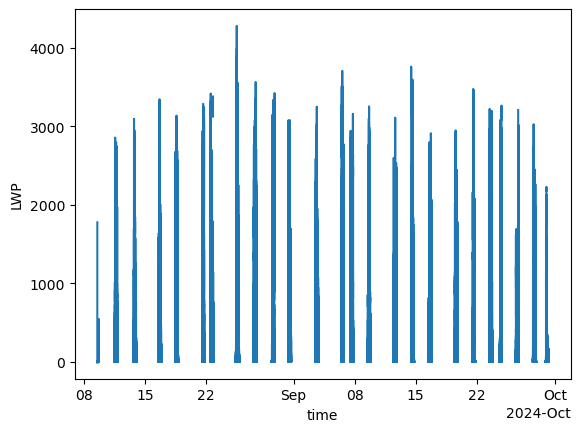

In [6]:
ds_hamp.LWP.plot()

## Combination of radar and radiometer

In [7]:
ds_hamp.time

<xarray.DataArray 'time' (time: 3750412)> Size: 30MB
array(['2024-08-09T05:03:25.000000000', '2024-08-09T05:03:25.250000000',
       '2024-08-09T05:03:25.500000000', ..., '2024-09-30T07:15:21.250000000',
       '2024-09-30T07:15:21.500000000', '2024-09-30T07:15:21.750000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 30MB 2024-08-09T05:03:25 ... 2024-09-30T07...

In [14]:
ds_hamp



<xarray.Dataset> Size: 3GB
Dimensions:               (time: 3750412, frequency: 25)
Coordinates:
  * frequency             (frequency) float32 100B 22.24 23.04 ... 188.3 190.8
  * time                  (time) datetime64[ns] 30MB 2024-08-09T05:03:25 ... ...
Data variables: (12/15)
    AziAng                (time, frequency) float32 375MB ...
    ElAng                 (time, frequency) float32 375MB ...
    RF                    (time, frequency) float64 750MB ...
    TBs                   (time, frequency) float32 375MB ...
    lat                   (time) float64 30MB ...
    lon                   (time) float64 30MB ...
    ...                    ...
    plane_pitch           (time) float64 30MB ...
    plane_roll            (time) float64 30MB ...
    IWV                   (time) float64 30MB ...
    IWP                   (time) float64 30MB ...
    TLWP                  (time) float64 30MB ...
    LWP                   (time) float64 30MB ...
Attributes: (12/16)
    Host-PC_Software_Version:     V9.45
    Radiometer_Software_Version:  V9.45
    Radiometer_System:             RPG-HATPRO
    creator_email:                jakob.deutloff@uni-hamburg.de, lukas.kluft@...
    creator_name:                 Jakob Deutloff, Lukas Kluft, Clara Bayley
    featureType:                  trajectoryProfile
    ...                           ...
    platform:                     HALO
    project:                      ORCESTRA, PERCUSION
    references:                   10.5194/amt-12-1815-2019, 10.5194/essd-13-5...
    summary:                      This dataset contains measurements from the...
    title:                        Radiometer Data from the Halo Microwave Pac...
    version:                      1.0

In [10]:
ds_r=ds_radar#.sel(time=slice('2024-08-09T09:00:05.097473000', '2024-08-12T10:52:06.121430000'))
ds_h=ds_hamp#.sel(time=slice('2024-08-09T09:00:05.097473000', '2024-08-12T10:52:06.121430000'))

In [11]:
## For large time deltas (eg between flights, radar outtakes) do not calculate mean over whole time slice
# checking time delta in bins
delta=ds_r.time[1:].values-ds_r.time[:-1].values

# Create a timedelta64 object representing 1.3 seconds in nanoseconds
threshold = np.timedelta64(int(1.3 * 1e9), 'ns')

# Generate the mask
mask = delta < threshold


In [15]:
%%time
labels_t=np.array(ds_r.time[1:],dtype='datetime64[ns]')

#grouping array in time intervals, with closed rigght edge. using time stamp of right edge

#ds_h_new=ds_h['IWV'].groupby_bins(ds_h.time,ds_r.time, labels=labels_t).mean()
#ds_h_new.time_bins

#ds_h_new = ds_h_new
for variable in ['IWV','LWP','IWP','TLWP']:
    print('processing ' + variable)
    ds_new=ds_h[variable].groupby_bins(ds_h.time,ds_r.time, labels=labels_t).mean().rename({"time_bins": "time"})
    ds_r[variable] = ds_new.where(mask== True, other=np.nan)
    print('saving ds for '+variable)
    #ds_r.to_netcdf('/work/um0203/u301032/master_thesis/retrieved_data/radar_with_condensate_loads_new_run.nc')
# now: 
## change coordinate names of new ds_h to time instead of bins
## use mask to recalculate mean from last 4 pulses.
## add new ds_h to radar
## save radar-array

processing IWV
saving ds for IWV
processing LWP
saving ds for LWP
processing IWP
saving ds for IWP
processing TLWP
saving ds for TLWP
CPU times: user 1h 23min 36s, sys: 4min 40s, total: 1h 28min 16s
Wall time: 1h 29min 24s


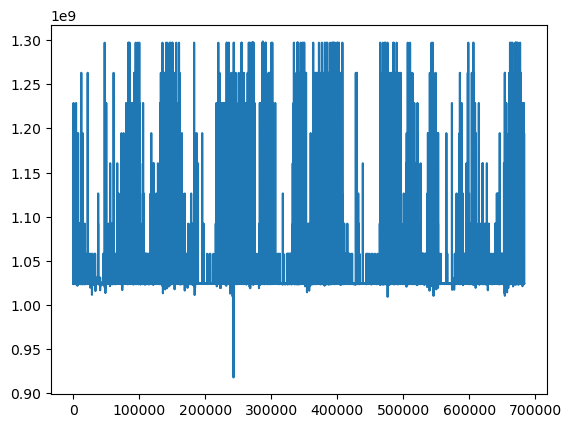

In [7]:
#plt.hist(int(delta))
plt.plot(delta[mask])


## Overview Tropics

(array([5.82917e+05, 1.26050e+04, 5.47100e+03, 3.61300e+03, 2.92500e+03,
        2.08300e+03, 9.86000e+02, 2.70000e+02, 5.30000e+01, 8.00000e+00]),
 array([5.57122348e-10, 4.14648590e+02, 8.29297180e+02, 1.24394577e+03,
        1.65859436e+03, 2.07324295e+03, 2.48789154e+03, 2.90254013e+03,
        3.31718872e+03, 3.73183731e+03, 4.14648590e+03]),
 <BarContainer object of 10 artists>)

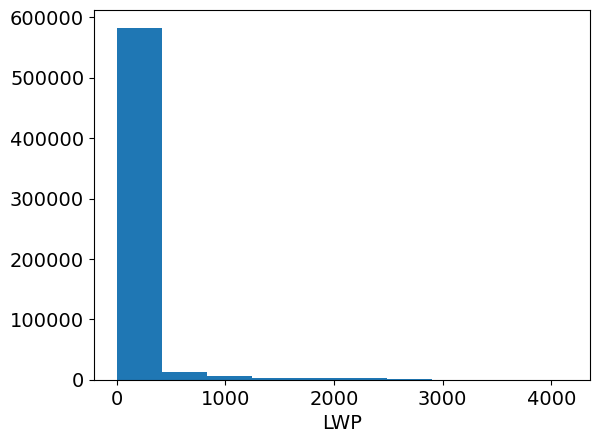

In [80]:
ds_radar.LWP.plot.hist()

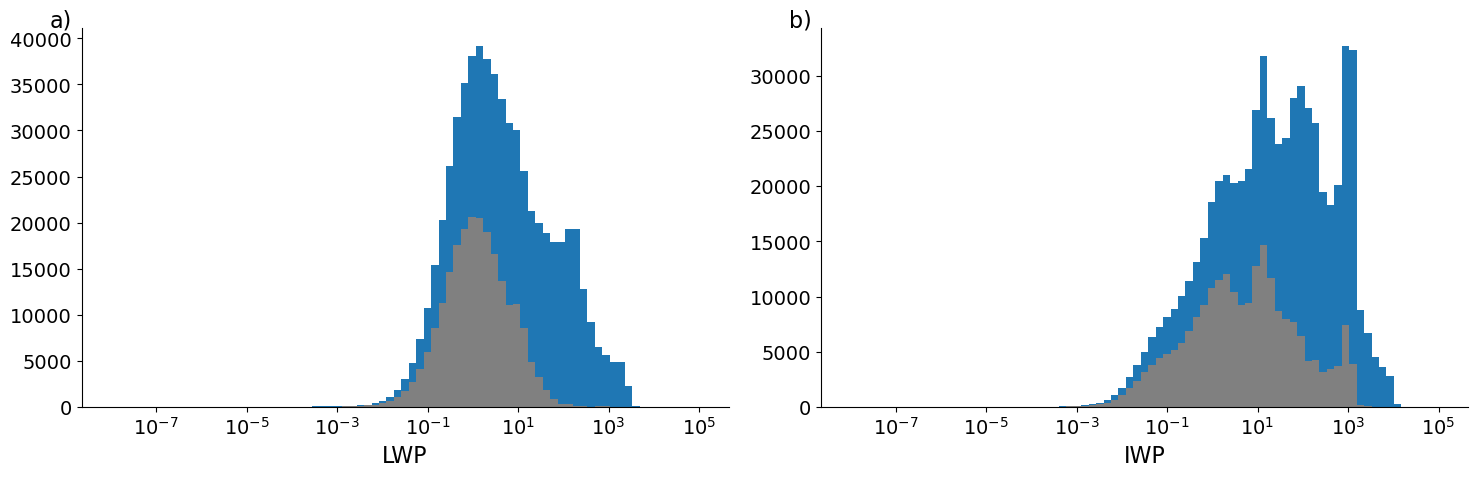

In [97]:
def plot_2_by_1(data, plottype,  variables = ['LWP','IWP'],savefig=False, filename = None):
    """
    convenient plotting for LWP and IWP
    plot types implemented so far:
    - hist
    data : if type hist, then format in the shape of [[train_IWV, test_IWV],[train_LWP, test_LWP],[train_IWP, test_IWP]]
    """
    plt.rcParams.update({'font.size': 14}) # labels in 16
    plt.rcParams['savefig.dpi'] = 400
    # Create figure with 1 row, 3 columns
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Loop over data and corresponding axes:
    for ax, da, variable, title in zip(axes, data, variables, ['a)','b)']):
        ax.xaxis.set_major_locator(ticker.LogLocator(base = 1))
        if plottype == 'hist':
            ax.hist(da,bins=np.logspace(-8,5,80))
            #ax.hist(da[da<10],bins=np.logspace(-8,5,80),color='gray')
            ax.hist(da[ds_radar['no clouds']],bins=np.logspace(-8,5,80),color='gray')
            #ax.hist(da[not ds_radar['no clouds']],bins=np.logspace(-8,5,80),color='grey')
            ax.set_xlabel(variable, fontsize=16)
            
        ax.set_xscale('log')   
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
                
        ax.text(-0.05, 1.05, title, transform=ax.transAxes,
          fontsize=16,  va='top')
        
        #ax.xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(1.0, 10.0) * 0.1, numticks=12))
        ax.xaxis.set_major_locator(ticker.LogLocator(base = 10))
    # Improve layout and display
    plt.tight_layout()
    #filename= "hist_traing_testing_set"
    if savefig:
        if filename is not None:
            plt.savefig(f'/home/u/u301032/orcestra/plots/{filename}.png')
            print('Plot saved')
        else:
            print('Please define filename. Otherwise saving of plot is not possible')        
    plt.show()


data=[ds_radar.LWP,ds_radar.IWP]
plot_2_by_1(data,'hist')

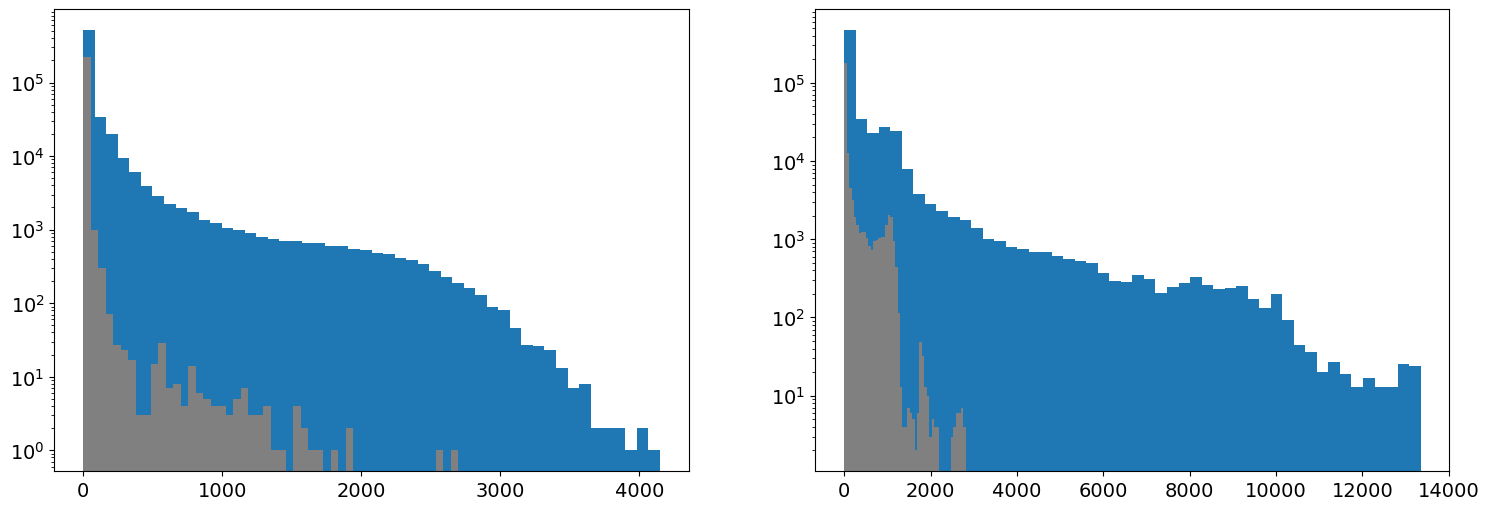

In [89]:
data=[ds_radar.LWP,ds_radar.IWP]
fig, axs = plt.subplots(1, 2,figsize=(18, 6))
for ax,da in zip(axs,data):
    ax.hist(da,bins=50)
    ax.hist(da[ds_radar['no clouds']],bins=50,color='gray')
    #ax1.set_ylim(top=ylim)
    #ax.set_xscale('log')
    ax.set_yscale('log')
plt.show()

## Visualization of masks

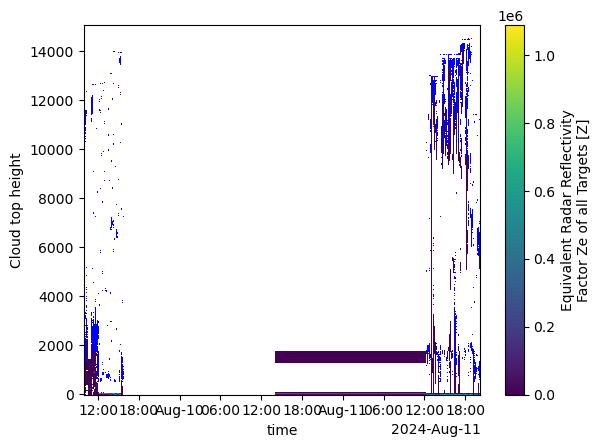

In [60]:
# visualising of radar maskl
ds=ds_radar.sel(time=slice('2024-08-09T09:00:05.097473000', '2024-08-12T10:52:06.121430000'))
ds.Zg.T.plot()
ds.CTH.plot(marker=',',linestyle='',color='b',markersize=3)

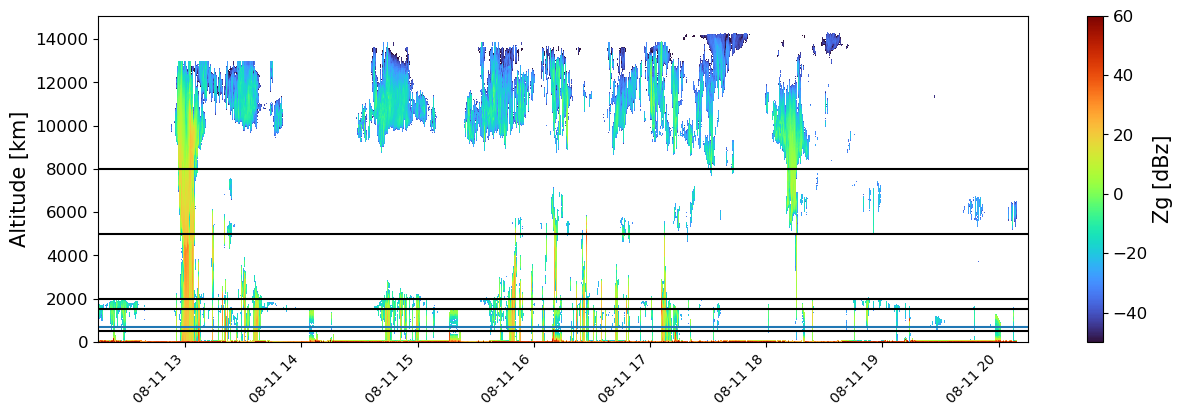

In [96]:
radar=ds_radar.sel(time=slice('2024-08-11T10:00:00','2024-08-11T22:00:00'))
hlines=True
# Plot radar reflectivities (Zg)
fig,axs =plt.subplots()
fig.set_figwidth(15)
im = axs.pcolormesh(
    radar.time, radar.height, 10*np.log10(radar.Zg.T), 
    vmin=-50, vmax=60, cmap='turbo', shading='nearest')
#axs.set_ylim(top=100)
axs.set_ylabel('Altitude [km]',fontsize=15)
#axs.yaxis.set_label_coords(-0.045,.5)
axs.tick_params(axis='y', labelsize=12)
if hlines == True:
    for limit in lower_limits:
        axs.axhline(limit,color='k')
    axs.axhline(700)
cbar = fig.colorbar(im, ax=axs)#, pad=-0.16,aspect=7.5)
cbar.set_label('Zg [dBz]',size=15)
cbar.ax.tick_params(labelsize=12)

fig.autofmt_xdate(rotation=45)

In [11]:
def save_plot(filename):
    plt.rcParams['savefig.dpi'] = 400
    plt.savefig(f'/home/u/u301032/orcestra/plots/{filename}.png')
    return "plot saved in /home/u/u301032/orcestra/plots/"

In [133]:
#mask_names = ['all clouds + rain', 'no clouds', 'only low level clouds', 'only mid level clouds', 'only upper level clouds', 'only high level clouds']
#mask_list = [mask_all, mask_none, mask_only_low, mask_only_mid, mask_only_upper, mask_only_high]

ds_new_masks = ds_radar

for  n in mask_names:
    # Add each mask as a DataArray with specified dimensions
    ds_new_masks[n] = xr.DataArray(
        df_masks[n].to_numpy().flatten(),
        dims=('time',),  # replace with actual dimensions if different
        coords={'time': ds_radar['time']},  # copy the 'time' coordinate
        name=n
    )
ds_new_masks

<xarray.Dataset> Size: 39GB
Dimensions:                       (height: 503, time: 683096)
Coordinates:
  * height                        (height) float64 4kB 0.0 30.0 ... 1.506e+04
  * time                          (time) datetime64[ns] 5MB 2024-08-09T09:52:...
Data variables: (12/77)
    DPS                           (time, height) float32 1GB ...
    DetuneFine                    (time) float32 3MB ...
    HSDco                         (time, height) float32 1GB ...
    HSDcx                         (time, height) float32 1GB ...
    ISDRco                        (time, height) float32 1GB ...
    ISDRcx                        (time, height) float32 1GB ...
    ...                            ...
    deep convection               (time) float64 5MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    clear-sky                     (time) float64 5MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    low level clouds              (time) float64 5MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    mid level clouds              (time) float64 5MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    upper level clouds            (time) float64 5MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    high level clouds             (time) float64 5MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
Attributes: (12/16)
    convention:     CF-1.0
    creator_email:  jakob.deutloff@uni-hamburg.de, lukas.kluft@mpimet.mpg.de,...
    creator_name:   Jakob Deutloff, Lukas Kluft, Clara Bayley
    featureType:    trajectoryProfile
    history:        The processing software is available at https://github.co...
    keywords:       Cloud Radar, HALO, ORCESTRA, PERCUSION, Tropical Atlantic
    ...             ...
    reference:      Ka Band Cloud Radar MIRA, METEK GmbH www.metek.de
    references:     10.5194/amt-12-1815-2019, 10.5194/essd-13-5545-2021
    summary:        This dataset contains measurements from the MIRA cloud ra...
    system:         HAXC
    title:          MIRA Cloud Radar Moments from the HALO Microwave Package ...
    version:        1.0

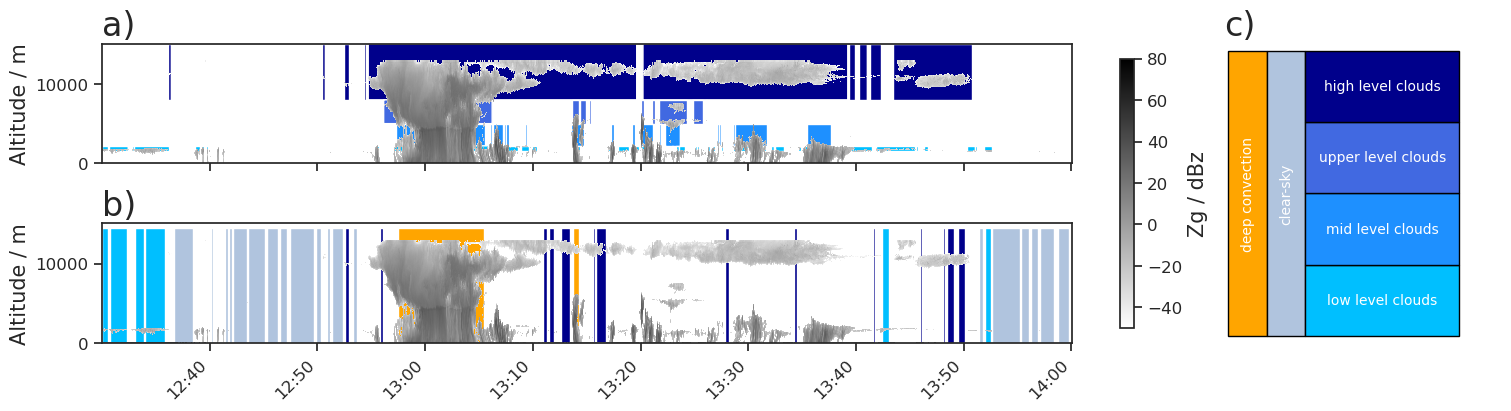

In [143]:
from matplotlib import patches
ds_radar=ds_new_masks
plt.rcParams['savefig.dpi'] = 400
radar=ds_radar.sel(time=slice('2024-08-11T12:30:00','2024-08-11T14:00:00'))
#colors=['orange','lightsteelblue','hotpink','violet','mediumorchid','cyan'] #['orange','magenta','deepskyblue','cornflowerblue','lightseagreen','teal']#
colors=['orange','lightsteelblue','deepskyblue','dodgerblue','royalblue','darkblue'] 
# Plot radar reflectivities (Zg)

#fig,(ax2,axs) =plt.subplots(nrows=2,ncols=1,sharex=True,constrained_layout=True)

fig,axd = plt.subplot_mosaic(
    """
    AD
    BD
    """,
    # set the height ratios between the rows
    height_ratios=[1,1],
    # set the width ratios between the columns
    width_ratios=[7,2],
    figsize=(15, 4) ,
    layout='constrained'
    #sharex=True
)
fig.set_figwidth(15)




#plot2
colors2=['darkblue','royalblue','dodgerblue','deepskyblue']#['teal','lightseagreen','cornflowerblue','deepskyblue','mediumblue']
for color,category, upper_limit, lower_limit in zip(colors2,categories, upper_limits, lower_limits):
    if category == "rain":  # rain needs different naming conventions
        variable_name = f"mask_{category}"
    else:
        variable_name = f"mask_{category}_level_cloud"
    axd['A'].fill_between(radar.time,lower_limit,y2=upper_limit, where=radar[variable_name], facecolor=color)#, alpha=.4,label='land == True')
axd['A'].set_ylabel('Altitude / m',fontsize=15)
#axs.yaxis.set_label_coords(-0.045,.5)
axd['A'].tick_params( labelsize=12)
im = axd['A'].pcolormesh(
    radar.time, radar.height, 10*np.log10(radar.Zg.T), 
    vmin=-50, vmax=80, cmap='binary', shading='nearest')
axd['A'].set_title('a)',  loc='left')#, fontsize='medium')

##
for color,mask, name in zip(colors,mask_list, mask_names):
    
    axd['B'].fill_between(radar.time,0,y2=14500,where=radar[name], facecolor=color)#where=radar[name]
axd['B'].set_ylabel('Altitude / m',fontsize=15)
#axs.yaxis.set_label_coords(-0.045,.5)
axd['B'].tick_params( labelsize=12)
im = axd['B'].pcolormesh(
    radar.time, radar.height, 10*np.log10(radar.Zg.T), 
    vmin=-50, vmax=80, cmap='binary', shading='nearest')

###
axd['B'].set_title('b)',  loc='left')
cbar = fig.colorbar(im, ax=[axd['A'],axd['B']],shrink=0.9)################################################
cbar.set_label('Zg / dBz',size=15)
cbar.ax.tick_params(labelsize=12)

myFmt = mdates.DateFormatter('%H:%M')
axd['B'].xaxis.set_major_formatter(myFmt)

fig.autofmt_xdate(rotation=45)
#plt.tight_layout()

axd['D'].set_xlim(0.9, 8.1)
axd['D'].set_ylim(0.9, 5.1)
axd['D'].axis('off')  # Hide axes


# Coordinates for rectangles
rects_info = [
    {'x': 1, 'y': 1, 'width': 1, 'height': 4, 'color': colors[0], 'label': mask_names[0]},  # bottom rectangle
    {'x': 2, 'y': 1, 'width': 1, 'height': 4, 'color': colors[1], 'label': mask_names[1]},  # above bottom
    # Stairs
    {'x': 3, 'y': 1, 'width': 4, 'height': 1, 'color': colors[2], 'label': mask_names[2]},
    {'x': 3, 'y': 2, 'width': 4, 'height': 1, 'color': colors[3], 'label': mask_names[3]},
    {'x': 3, 'y': 3, 'width': 4, 'height': 1, 'color': colors[4], 'label': mask_names[4]},
    {'x': 3, 'y': 4, 'width': 4, 'height': 1, 'color': colors[5], 'label': mask_names[5]},
]

# Add rectangles and labels
for i, rect in enumerate(rects_info):
    # Draw rectangle
    patch = patches.Rectangle(
        (rect['x'], rect['y']),
        rect['width'],
        rect['height'],
        facecolor=rect['color'],
        edgecolor='black'
    )
    axd['D'].add_patch(patch)
    
    # Decide whether to rotate text for first two rectangles
    if i < 2:
        rotation_angle = 90  # Vertical text
        va = 'center'
        ha = 'center'
        # Position text centered inside rectangle
        text_x = rect['x'] + rect['width']/2
        text_y = rect['y'] + rect['height']/2
    else:
        rotation_angle = 0
        # Place text just outside the rectangle to the right
        text_x = rect['x'] + rect['width'] /2
        text_y = rect['y'] + rect['height']/2
    
    axd['D'].text(
        text_x,
        text_y,
        rect['label'],
        verticalalignment='center',
        horizontalalignment='center',
        fontsize=10,
        rotation=rotation_angle,
        color='white'
    )

axd['D'].set_title('c)',  loc='left')
#plt.tight_layout()
#filename='2024-08-11_v2'
   
#plt.savefig(f'/home/u/u301032/orcestra/plots/cloud_masking_{filename}.png')
plt.show()

#plt.figure(figsize=(20, 4)) 

In [130]:
#mask_names = ['all clouds + rain','no clouds','only low level clouds','only mid level clouds','only upper level clouds','only high level clouds']
#mask_list = [mask_all,mask_none,mask_only_low,mask_only_mid,mask_only_upper ,mask_only_high]
#mask_names = ['all clouds + rain','no clouds','only low level clouds','only mid level clouds','only upper level clouds','only high level clouds']
#mask_list = [mask_all,mask_none,mask_only_low,mask_only_mid,mask_only_upper ,mask_only_high]
ds_radar=ds_new_masks
plt.rcParams['savefig.dpi'] = 400
radar=ds_radar.sel(time=slice('2024-08-11T12:30:00','2024-08-11T14:00:00'))
#colors=['orange','lightsteelblue','hotpink','violet','mediumorchid','cyan'] #['orange','magenta','deepskyblue','cornflowerblue','lightseagreen','teal']#
colors=['orange','lightsteelblue','deepskyblue','dodgerblue','royalblue','darkblue'] 
# Plot radar reflectivities (Zg)

fig,(ax2,axs) =plt.subplots(nrows=2,ncols=1,sharex=True,constrained_layout=True)


fig.set_figwidth(15)
for color,mask, name in zip(colors,mask_list, mask_names):
    
    axs.fill_between(radar.time,0,y2=14500,where=radar[name], facecolor=color)#where=radar[name]
axs.set_ylabel('Altitude / m',fontsize=15)
#axs.yaxis.set_label_coords(-0.045,.5)
axs.tick_params( labelsize=12)
im = axs.pcolormesh(
    radar.time, radar.height, 10*np.log10(radar.Zg.T), 
    vmin=-50, vmax=80, cmap='binary', shading='nearest')
cbar = fig.colorbar(im, ax=axs)#, pad=-0.16,aspect=7.5)
cbar.set_label('Zg / dBz',size=15)
cbar.ax.tick_params(labelsize=12)


#plot2
colors2=['darkblue','royalblue','dodgerblue','deepskyblue']#['teal','lightseagreen','cornflowerblue','deepskyblue','mediumblue']
for color,category, upper_limit, lower_limit in zip(colors2,categories, upper_limits, lower_limits):
    if category == "rain":  # rain needs different naming conventions
        variable_name = f"mask_{category}"
    else:
        variable_name = f"mask_{category}_level_cloud"
    ax2.fill_between(radar.time,lower_limit,y2=upper_limit, where=radar[variable_name], facecolor=color)#, alpha=.4,label='land == True')
ax2.set_ylabel('Altitude / m',fontsize=15)
#axs.yaxis.set_label_coords(-0.045,.5)
ax2.tick_params( labelsize=12)
im = ax2.pcolormesh(
    radar.time, radar.height, 10*np.log10(radar.Zg.T), 
    vmin=-50, vmax=80, cmap='binary', shading='nearest')

myFmt = mdates.DateFormatter('%H:%M')
axs.xaxis.set_major_formatter(myFmt)

fig.autofmt_xdate(rotation=45)
#plt.tight_layout()

filename='2024-08-11'
   
#plt.savefig(f'/home/u/u301032/orcestra/plots/cloud_masking_{filename}.png')
plt.show()



NameError: name 'ds_new_masks' is not defined

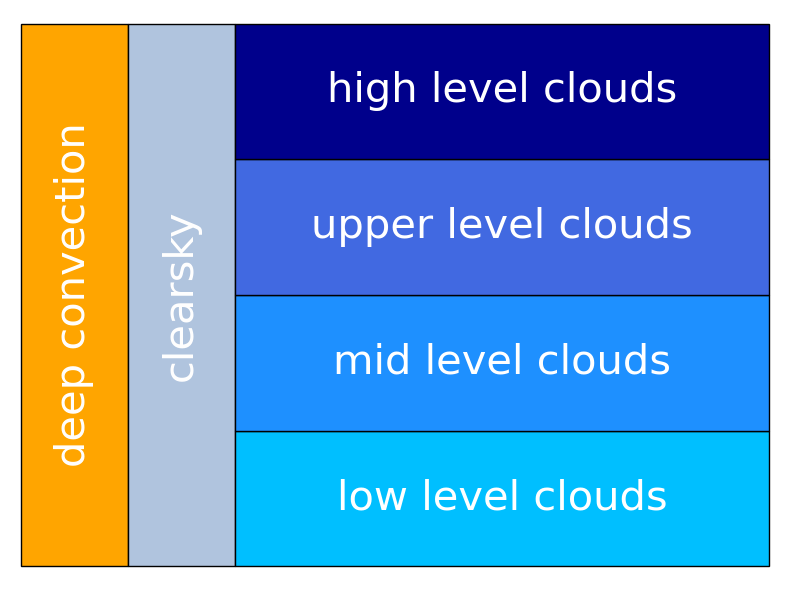

In [52]:
from matplotlib import patches

plt.rcParams['savefig.dpi'] = 400
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(0.9, 8.1)
ax.set_ylim(0.9, 5.1)
ax.axis('off')  # Hide axes

mask_names = ['deep convection','clearsky','low level clouds','mid level clouds','upper level clouds','high level clouds']

# Coordinates for rectangles
rects_info = [
    {'x': 1, 'y': 1, 'width': 1, 'height': 4, 'color': colors[0], 'label': mask_names[0]},  # bottom rectangle
    {'x': 2, 'y': 1, 'width': 1, 'height': 4, 'color': colors[1], 'label': mask_names[1]},  # above bottom
    # Stairs
    {'x': 3, 'y': 1, 'width': 5, 'height': 1, 'color': colors[2], 'label': mask_names[2]},
    {'x': 3, 'y': 2, 'width': 5, 'height': 1, 'color': colors[3], 'label': mask_names[3]},
    {'x': 3, 'y': 3, 'width': 5, 'height': 1, 'color': colors[4], 'label': mask_names[4]},
    {'x': 3, 'y': 4, 'width': 5, 'height': 1, 'color': colors[5], 'label': mask_names[5]},
]

# Add rectangles and labels
for i, rect in enumerate(rects_info):
    # Draw rectangle
    patch = patches.Rectangle(
        (rect['x'], rect['y']),
        rect['width'],
        rect['height'],
        facecolor=rect['color'],
        edgecolor='black'
    )
    ax.add_patch(patch)
    
    # Decide whether to rotate text for first two rectangles
    if i < 2:
        rotation_angle = 90  # Vertical text
        va = 'center'
        ha = 'center'
        # Position text centered inside rectangle
        text_x = rect['x'] + rect['width']/2
        text_y = rect['y'] + rect['height']/2
    else:
        rotation_angle = 0
        # Place text just outside the rectangle to the right
        text_x = rect['x'] + rect['width'] /2
        text_y = rect['y'] + rect['height']/2
    
    ax.text(
        text_x,
        text_y,
        rect['label'],
        verticalalignment='center',
        horizontalalignment='center',
        fontsize=30,
        rotation=rotation_angle,
        color='white'
    )



plt.tight_layout()
filename='v1'
plt.savefig(f'/home/u/u301032/orcestra/plots/chart_levels_{filename}.png')
plt.show()


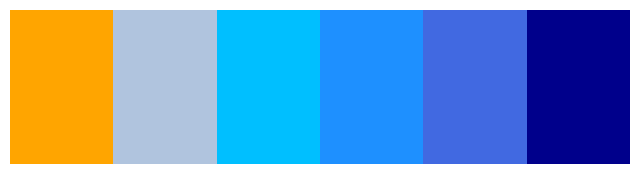

In [55]:
# Number of stripes
num_stripes = len(colors)

# Create a figure and axis
fig, ax = plt.subplots(figsize=(8, 2))

# Draw vertical stripes
for i, color in enumerate(colors):
    # Define the position of each stripe
    left = i / num_stripes
    right = (i + 1) / num_stripes
    # Add a rectangle patch for each stripe
    rect = plt.Rectangle((left, 0), width=right - left, height=1, facecolor=color, edgecolor='none')
    ax.add_patch(rect)

# Set the limits and remove axes for a clean look
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

plt.show()

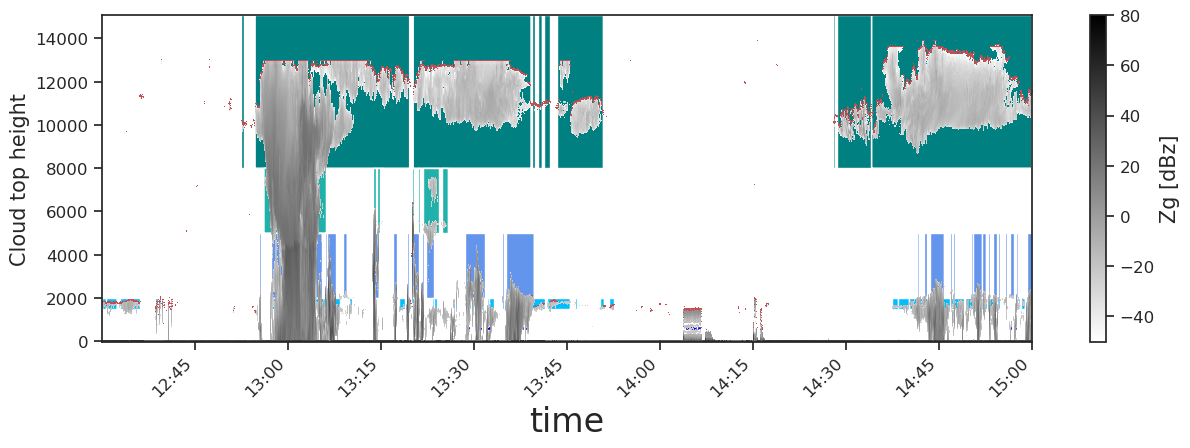

In [128]:
radar=ds_radar.sel(time=slice('2024-08-11T12:30:00','2024-08-11T15:00:00'))
colors=['teal','lightseagreen','cornflowerblue','deepskyblue','mediumblue']
# Plot radar reflectivities (Zg)
fig,axs =plt.subplots()
fig.set_figwidth(15)
for color,category, upper_limit, lower_limit in zip(colors,categories, upper_limits, lower_limits):
    if category == "rain":  # rain needs different naming conventions
        variable_name = f"mask_{category}"
    else:
        variable_name = f"mask_{category}_level_cloud"
    axs.fill_between(radar.time,lower_limit,y2=upper_limit, where=radar[variable_name], facecolor=color)#, alpha=.4,label='land == True')
axs.set_ylabel('Altitude [km]',fontsize=15)
#axs.yaxis.set_label_coords(-0.045,.5)
axs.tick_params( labelsize=12)
im = axs.pcolormesh(
    radar.time, radar.height, 10*np.log10(radar.Zg.T), 
    vmin=-50, vmax=80, cmap='binary', shading='nearest')
cbar = fig.colorbar(im, ax=axs)#, pad=-0.16,aspect=7.5)
cbar.set_label('Zg [dBz]',size=15)
cbar.ax.tick_params(labelsize=12)

radar.CTH.plot(marker=',',linestyle='',color='r',markersize=3)

myFmt = mdates.DateFormatter('%H:%M')
axs.xaxis.set_major_formatter(myFmt)

fig.autofmt_xdate(rotation=45)
#save_plot('cloud_masking_2024-08-11')


2024-09-16


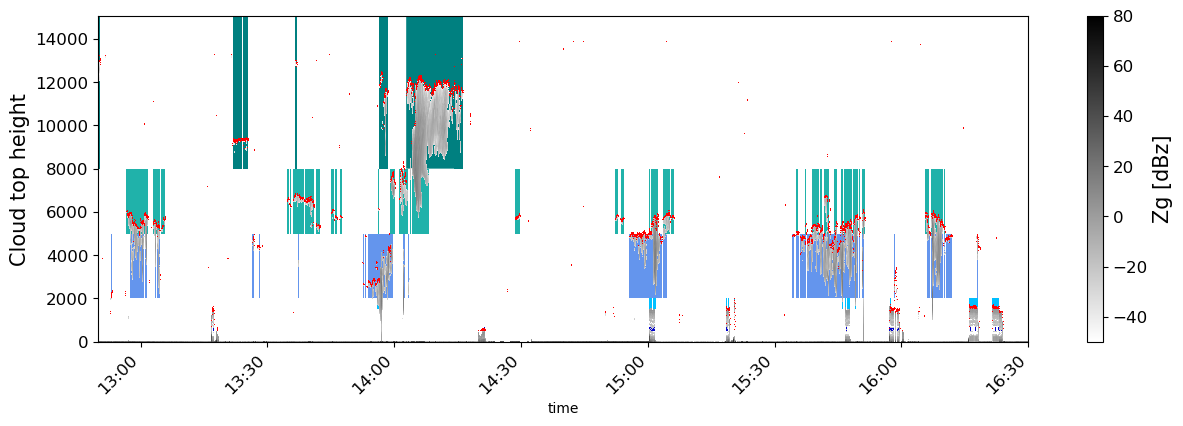

In [9]:
radar=ds_radar.sel(time=slice('2024-09-16T12:50:00','2024-09-16T16:30:00'))
colors=['teal','lightseagreen','cornflowerblue','deepskyblue','mediumblue']
# Plot radar reflectivities (Zg)
fig,axs =plt.subplots()
fig.set_figwidth(15)
for color,category, upper_limit, lower_limit in zip(colors,categories, upper_limits, lower_limits):
    if category == "rain":  # rain needs different naming conventions
        variable_name = f"mask_{category}"
    else:
        variable_name = f"mask_{category}_level_cloud"
    axs.fill_between(radar.time,lower_limit,y2=upper_limit, where=radar[variable_name], facecolor=color)#, alpha=.4,label='land == True')
axs.set_ylabel('Altitude [km]',fontsize=15)
#axs.yaxis.set_label_coords(-0.045,.5)
axs.tick_params( labelsize=12)
im = axs.pcolormesh(
    radar.time, radar.height, 10*np.log10(radar.Zg.T), 
    vmin=-50, vmax=80, cmap='binary', shading='nearest')
cbar = fig.colorbar(im, ax=axs)#, pad=-0.16,aspect=7.5)
cbar.set_label('Zg [dBz]',size=15)
cbar.ax.tick_params(labelsize=12)

radar.CTH.plot(marker=',',linestyle='',color='r',markersize=3)

myFmt = mdates.DateFormatter('%H:%M')
axs.xaxis.set_major_formatter(myFmt)

fig.autofmt_xdate(rotation=45)
print('2024-09-16')

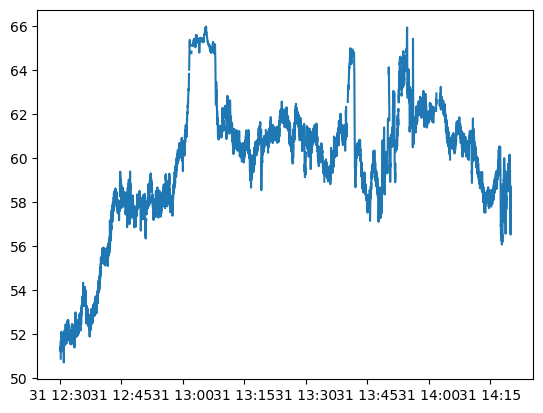

In [31]:
plt.plot(radar.IWV.time,radar.IWV)

2024-08-31


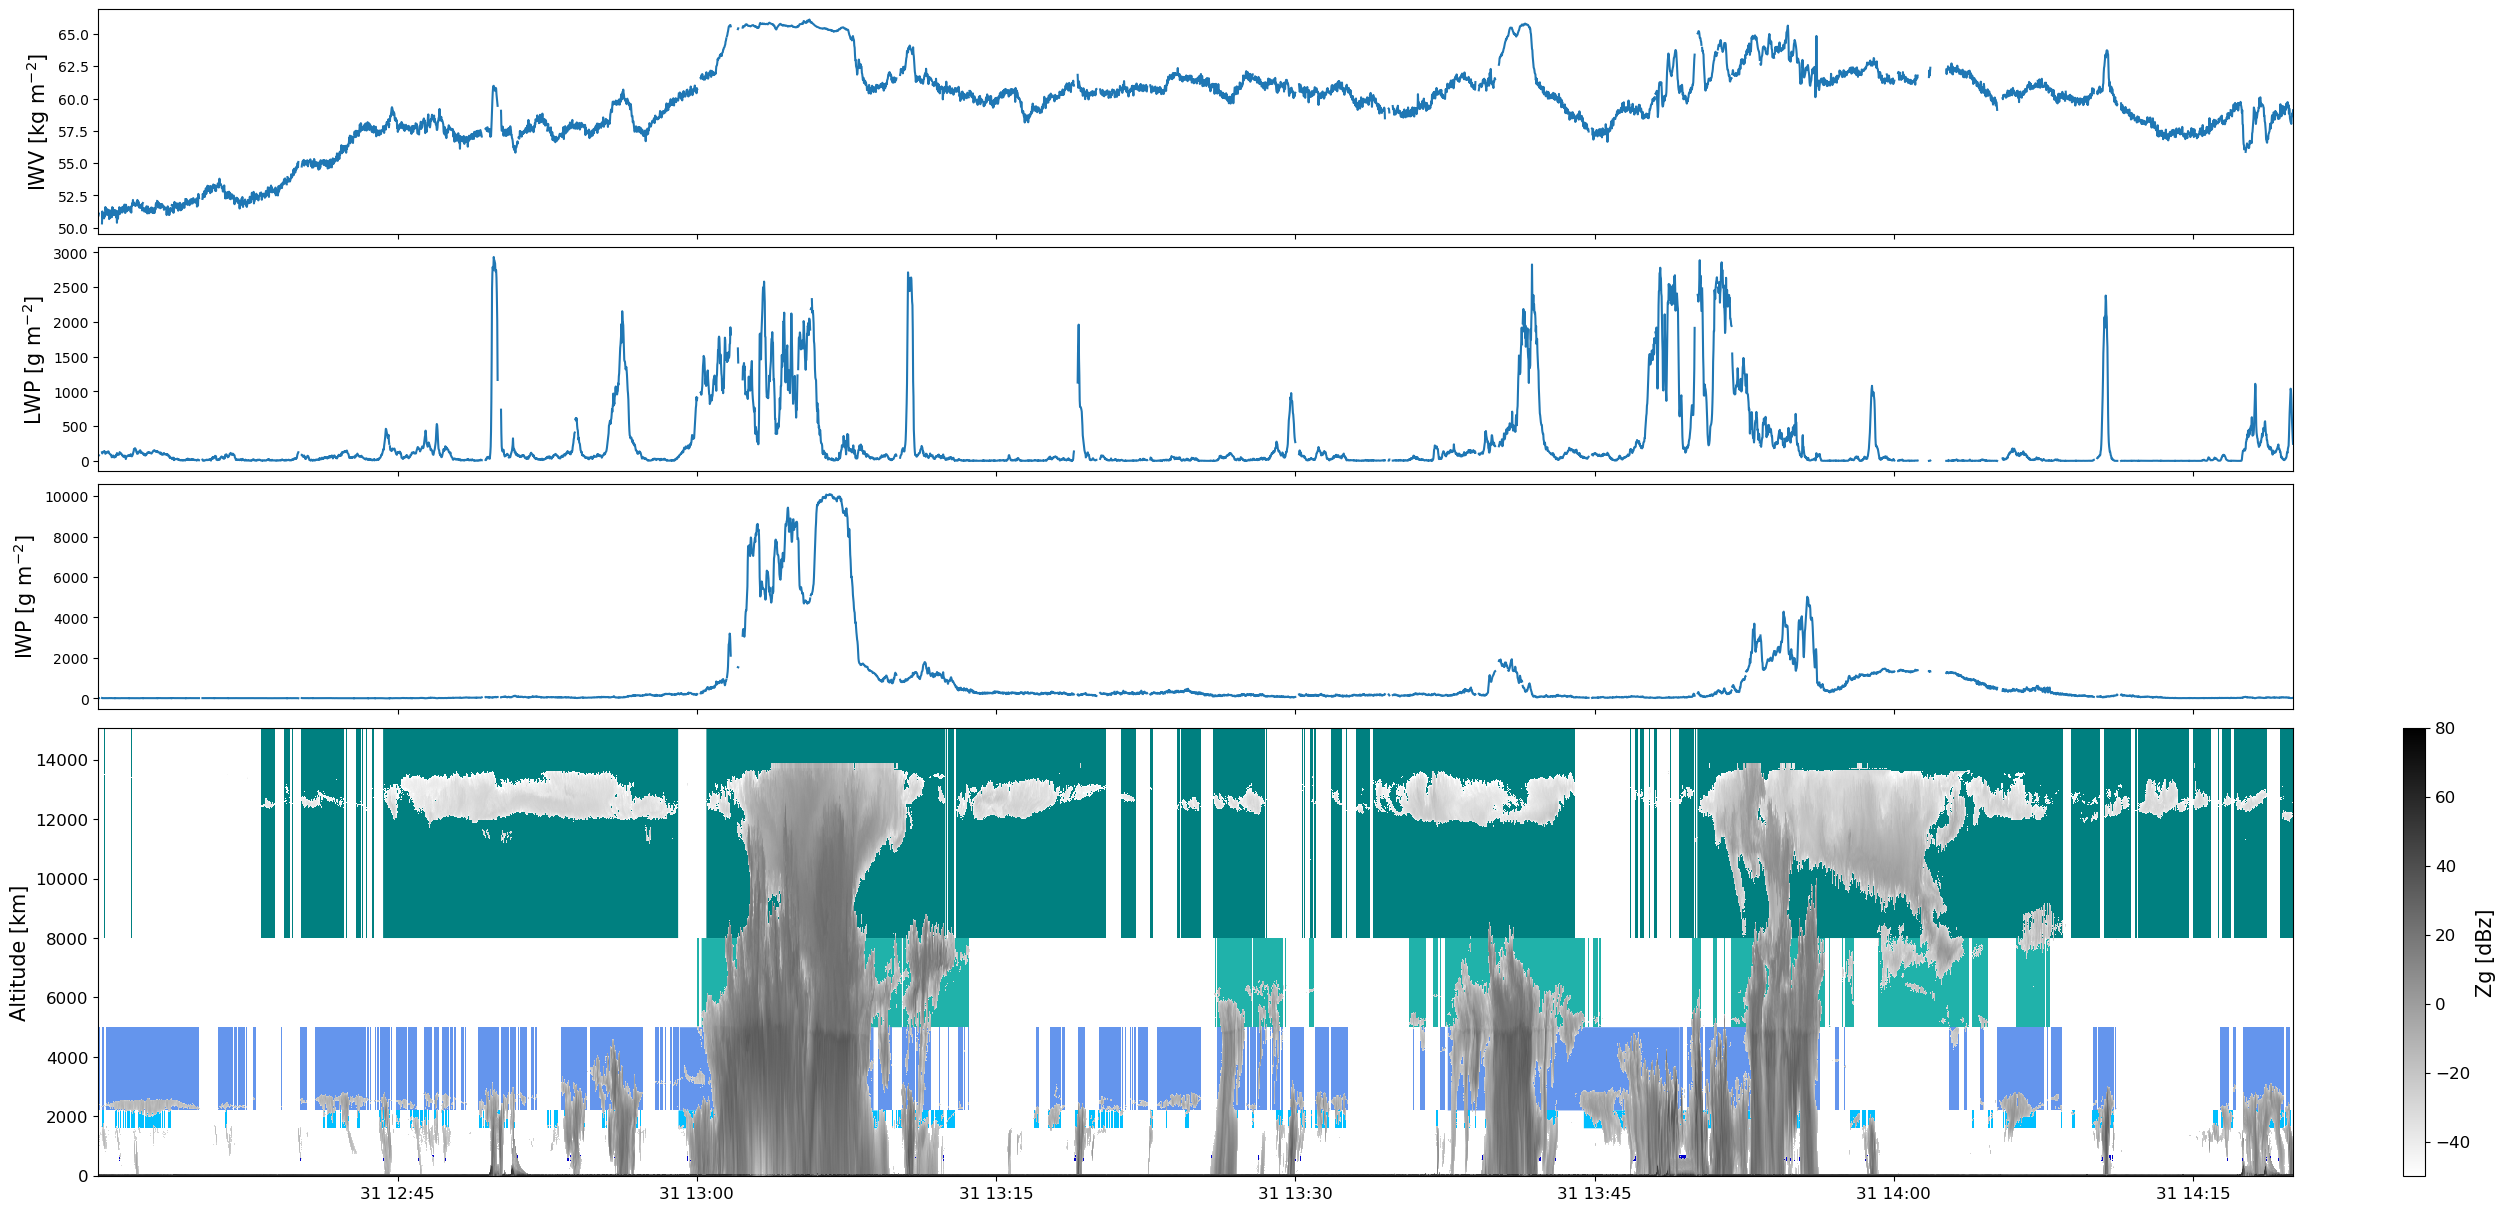

In [29]:
radar=ds_radar.sel(time=slice('2024-08-31T12:30:00','2024-08-31T14:20:00'))
colors=['teal','lightseagreen','cornflowerblue','deepskyblue','mediumblue']
# Plot radar reflectivities (Zg)
#fig,axs =plt.subplots(nrows=4,ncols=1)
fig, axs = plt.subplots(nrows=4,ncols=1,
                        sharex=True,
                        figsize=(25,12),
                        gridspec_kw={'height_ratios': [1,1,1,2]},
                        constrained_layout=True)
axs[0].plot(radar.IWV.time,radar.IWV)
axs[0].set_ylabel('IWV [kg m$^{-2}$]',color='black',fontsize=15)

axs[1].plot(radar.LWP.time,radar.LWP)
axs[1].set_ylabel('LWP [g m$^{-2}$]',color='black',fontsize=15)

axs[2].plot(radar.IWP.time,radar.IWP)
axs[2].set_ylabel('IWP [g m$^{-2}$]',color='black',fontsize=15)

for color,category, upper_limit, lower_limit in zip(colors,categories, upper_limits, lower_limits):
    if category == "rain":  # rain needs different naming conventions
        variable_name = f"mask_{category}"
    else:
        variable_name = f"mask_{category}_level_cloud"
    axs[3].fill_between(radar.time,lower_limit,y2=upper_limit, where=radar[variable_name], facecolor=color)#, alpha=.4,label='land == True')
axs[3].set_ylabel('Altitude [km]',fontsize=15)
#axs.yaxis.set_label_coords(-0.045,.5)
axs[3].tick_params( labelsize=12)
im = axs[3].pcolormesh(
    radar.time, radar.height, 10*np.log10(radar.Zg.T), 
    vmin=-50, vmax=80, cmap='binary', shading='nearest')
cbar = fig.colorbar(im, ax=axs[3])#, pad=-0.16,aspect=7.5)
cbar.set_label('Zg [dBz]',size=15)
cbar.ax.tick_params(labelsize=12)

#axs[3].plot(radar.CTH,marker=',',linestyle='',color='r',markersize=3)
#axs[3].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
#myFmt = mdates.DateFormatter('%H:%M')
#axs.xaxis.set_major_formatter(myFmt)

#fig.autofmt_xdate(rotation=45)
#save_plot('cloud_masking_2024-08-11')
print('2024-08-31')
filename='cloud_masking_2024-08-31'
#plt.savefig(f'/home/u/u301032/orcestra/plots/{filename}.png')

## condensate loads compared with cloud levels

### Creating Masks 

In [12]:
ds_radar

<xarray.Dataset> Size: 298MB
Dimensions:                       (height: 503, time: 5274)
Coordinates:
  * height                        (height) float64 4kB 0.0 30.0 ... 1.506e+04
  * time                          (time) datetime64[ns] 42kB 2024-08-11T12:30...
Data variables: (12/69)
    DPS                           (time, height) float32 11MB ...
    DetuneFine                    (time) float32 21kB ...
    HSDco                         (time, height) float32 11MB ...
    HSDcx                         (time, height) float32 11MB ...
    ISDRco                        (time, height) float32 11MB ...
    ISDRcx                        (time, height) float32 11MB ...
    ...                            ...
    mask_rain                     (time) bool 5kB False False ... False False
    IWV                           (time) float64 42kB ...
    LWP                           (time) float64 42kB ...
    IWP                           (time) float64 42kB ...
    TLWP                          (time) float64 42kB ...
    mask_rain_or_low_level_cloud  (time) bool 5kB True False ... False False
Attributes: (12/16)
    convention:     CF-1.0
    creator_email:  jakob.deutloff@uni-hamburg.de, lukas.kluft@mpimet.mpg.de,...
    creator_name:   Jakob Deutloff, Lukas Kluft, Clara Bayley
    featureType:    trajectoryProfile
    history:        The processing software is available at https://github.co...
    keywords:       Cloud Radar, HALO, ORCESTRA, PERCUSION, Tropical Atlantic
    ...             ...
    reference:      Ka Band Cloud Radar MIRA, METEK GmbH www.metek.de
    references:     10.5194/amt-12-1815-2019, 10.5194/essd-13-5545-2021
    summary:        This dataset contains measurements from the MIRA cloud ra...
    system:         HAXC
    title:          MIRA Cloud Radar Moments from the HALO Microwave Package ...
    version:        1.0

In [4]:
#
# all masks True
mask_all = np.all([ds_radar.mask_rain, ds_radar.mask_low_level_cloud,  ds_radar.mask_mid_level_cloud,  ds_radar.mask_upper_level_cloud,  ds_radar.mask_high_level_cloud],axis=0)
mask_none= ds_radar.CTH.isnull()


In [5]:
mask_no_low = np.any([ds_radar.mask_rain,   ds_radar.mask_mid_level_cloud,  ds_radar.mask_upper_level_cloud,  ds_radar.mask_high_level_cloud],axis=0)
mask_only_low = np.logical_and(ds_radar.mask_low_level_cloud,np.logical_not(mask_no_low))


mask_no_high = np.any([ds_radar.mask_rain, ds_radar.mask_rain_or_low_level_cloud, ds_radar.mask_low_level_cloud,  ds_radar.mask_mid_level_cloud,  ds_radar.mask_upper_level_cloud],axis=0)
mask_only_high = np.logical_and(ds_radar.mask_high_level_cloud,np.logical_not(mask_no_high))


mask_no_mid = np.any([ds_radar.mask_rain, ds_radar.mask_rain_or_low_level_cloud, ds_radar.mask_low_level_cloud,  ds_radar.mask_upper_level_cloud,  ds_radar.mask_high_level_cloud],axis=0)
mask_only_mid = np.logical_and(ds_radar.mask_mid_level_cloud,np.logical_not(mask_no_mid))


mask_no_upper = np.any([ds_radar.mask_rain, ds_radar.mask_rain_or_low_level_cloud, ds_radar.mask_low_level_cloud,  ds_radar.mask_mid_level_cloud,  ds_radar.mask_high_level_cloud],axis=0)
mask_only_upper = np.logical_and(ds_radar.mask_upper_level_cloud,np.logical_not(mask_no_upper))



In [6]:
mask_list = [mask_all,mask_none,mask_only_low,mask_only_mid,mask_only_upper ,mask_only_high]

mask_names = ['deep convection','clear-sky','low level clouds','mid level clouds','upper level clouds','high level clouds']
   

In [7]:
# pandas dataframe with masks, using a rolling window exluding the previous and following 3 timesteps
df_masks=pd.DataFrame(np.array(mask_list).T,columns=[mask_names]).rolling(window=7,center=True).min()

In [8]:
df_masks=df_masks.fillna(0)
i=1
for name in mask_names:
    df_masks[name]=df_masks[name]*i
    i+=1

In [9]:
df_cloud_type= df_masks.sum(axis=1).astype(int)
i=1
df_cloud_type.replace(0, np.nan, inplace=True)
for name in mask_names:
    df_cloud_type.replace(i, name, inplace=True)
    i+=1
df_cloud_type

0               NaN
1               NaN
2               NaN
3         clear-sky
4         clear-sky
            ...    
683091    clear-sky
683092    clear-sky
683093          NaN
683094          NaN
683095          NaN
Length: 683096, dtype: object

In [10]:
# Combine LWP, IWP, cloud type and ITCZ location to a single df
df_all=pd.DataFrame(np.array([ds_radar.LWP,ds_radar.IWP,df_cloud_type]).T,columns=['LWP','IWP','cloud type'])
df_all['ITCZ'] = np.where(ds_radar.IWV>48, 'within','outside')
df_all.head()
df_all.describe()

,LWP,IWP,cloud type,ITCZ
count,610931.000000,610931.000000,430320,683096
unique,610780.000000,610677.000000,6,2
top,102.781849,86.434772,clear-sky,within
freq,2.000000,2.000000,252026,442402


In [11]:
df =pd.DataFrame(np.array([ds_radar.LWP.where(ds_radar.LWP>25),ds_radar.IWP.where(ds_radar.IWP>50),df_cloud_type]).T,columns=['LWP','IWP','cloud type'])
df['ITCZ'] = np.where(ds_radar.IWV>48, 'within','outside')
df.head()#ds_radar.LWP.where(ds_radar.LWP>1).min()
df.describe()

,LWP,IWP,cloud type,ITCZ
count,157068.000000,260857.000000,430320,683096
unique,157018.000000,260709.000000,6,2
top,134.194305,909.262573,clear-sky,within
freq,2.000000,2.000000,252026,442402


In [12]:
df_melted=df.melt(id_vars=['ITCZ','cloud type'], value_vars=[ 'LWP','IWP'])#,                         var_name='Variable', value_name='Value')
df_melted.head()

df_all_melted=df_all.melt(id_vars=['ITCZ','cloud type'], value_vars=[ 'LWP','IWP'])#,                         var_name='Variable', value_name='Value')


In [14]:
ds_hamp.IWP

<xarray.DataArray 'IWP' (time: 3750412)> Size: 30MB
array([nan, nan, nan, ..., nan, nan, nan])
Coordinates:
  * time     (time) datetime64[ns] 30MB 2024-08-09T05:03:25 ... 2024-09-30T07...

In [21]:

df_all.describe()

,LWP,IWP,cloud type,ITCZ
count,610931.000000,610931.000000,436019,683096
unique,610780.000000,610677.000000,6,2
top,102.781849,86.434772,clear-sky,within
freq,2.000000,2.000000,252026,442402


### Overview 

In [13]:

np.concat((np.arange(0,10,1),np.arange(0,100,10)))

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9,  0, 10, 20, 30, 40, 50, 60,
       70, 80, 90])

In [103]:
np.round((1-df['LWP'].count()/df_all['LWP'].count(),1-df['IWP'].count()/df_all['IWP'].count()),4)*100

pd.DataFrame({'Column1': d[ 0], 'Column2': d[ 1]},index=0)

TypeError: Index(...) must be called with a collection of some kind, 0 was passed

In [25]:
#LWP observation above value
print('above 20g:',ds_radar.LWP.where(ds_radar.LWP>20).count()/ds_radar.LWP.count().values,'%')
print(' above 50g:',ds_radar.LWP.where(ds_radar.LWP>50).count()/ds_radar.LWP.count(),'%')
print(' above 500g:',ds_radar.LWP.where(ds_radar.LWP>500).count()/ds_radar.LWP.count(),'%')



above 20g: <xarray.DataArray 'LWP' ()> Size: 8B
array(0.27688397) %
 above 50g: <xarray.DataArray 'LWP' ()> Size: 8B
array(0.19897828) %
 above 500g: <xarray.DataArray 'LWP' ()> Size: 8B
array(0.03929413) %


In [81]:
df#.count()#/df_all.count())

,LWP,IWP,cloud type,ITCZ
0,NaN,NaN,NaN,outside
1,NaN,NaN,NaN,outside
2,NaN,NaN,NaN,outside
3,NaN,NaN,clear-sky,outside
4,NaN,NaN,clear-sky,outside
...,...,...,...,...
683091,NaN,NaN,clear-sky,outside
683092,NaN,NaN,clear-sky,outside
683093,NaN,NaN,NaN,outside
683094,NaN,NaN,NaN,outside


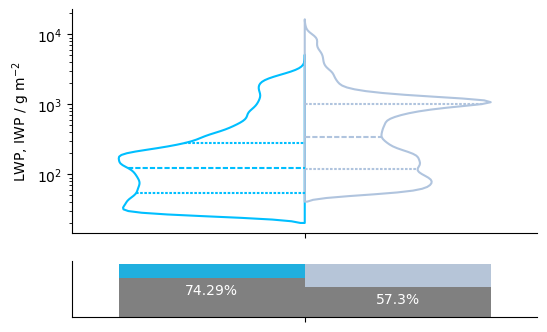

In [13]:
plt.rcParams['savefig.dpi'] = 400
fig, (ax1,ax2) = plt.subplots(2, 1, figsize=(6, 4), height_ratios=(4, 1),sharex=True)
my_pal = {'LWP':'deepskyblue','IWP':'lightsteelblue'}


#sns.boxplot(x='ITCZ', y='value', hue='variable', data=df_melted,log_scale=True,palette=my_pal,legend=False)
sns.violinplot( y='value',  hue='variable', data=df_melted,log_scale=True,palette=my_pal,legend=False,split=True, inner="quart", fill=False,ax=ax1)
ax1.spines[['right', 'top']].set_visible(False)
ax1.set_ylabel('LWP, IWP / g m$^{-2}$')

d=np.round((1-df['LWP'].count()/df_all['LWP'].count(),1-df['IWP'].count()/df_all['IWP'].count()),4)*100
d=pd.DataFrame([d,d],columns=['LWP','IWP'])#my_pal = {'LWP':'deepskyblue','IWP':'lightsteelblue'}
d=d.melt()
grey_pal = {'LWP':'grey','IWP':'grey'}
sns.barplot(data=d,hue='variable',y=100,palette=my_pal,legend=False,ax=ax2)
sns.barplot(data=d,hue='variable',y='value',palette=grey_pal,legend=False,ax=ax2)
ax2.spines[['right', 'top',]].set_visible(False)
ax2.set( ylabel='', yticks=[])

p_start=(int(len(plt.gca().patches)/2))
for p in plt.gca().patches[p_start:]:
    width = p.get_width()
    height = p.get_height()
    value =  height
    #if not percentage.empty:
    plt.text(p.get_x() + width / 2, value-10, f"{value}%", ha="center", va="top", color='white')

filename= "all_variables"
#plt.savefig(f'/home/u/u301032/orcestra/plots/climatology_{filename}.png')

plt.show()

In [17]:
df_all

,LWP,IWP,cloud type,ITCZ
0,NaN,NaN,NaN,outside
1,NaN,NaN,NaN,outside
2,NaN,NaN,NaN,outside
3,NaN,NaN,clear-sky,outside
4,NaN,NaN,clear-sky,outside
...,...,...,...,...
683091,NaN,NaN,clear-sky,outside
683092,NaN,NaN,clear-sky,outside
683093,NaN,NaN,NaN,outside
683094,NaN,NaN,NaN,outside


In [14]:
d=df.groupby('ITCZ').count()
d['LWP']=25
d['IWP']=50
#d=d.groupby('ITCZ').mean()
d=d.reset_index().melt(id_vars=['ITCZ'], value_vars=[ 'LWP','IWP'])
d

d=df
d['LWP']=25
d['IWP']=50
#d=d.groupby('ITCZ').mean()
#d=d.reset_index().melt(id_vars=['ITCZ'], value_vars=[ 'LWP','IWP'])
d.melt(id_vars=['ITCZ','cloud type'], value_vars=[ 'LWP','IWP'])#

,ITCZ,cloud type,variable,value
0,outside,NaN,LWP,25
1,outside,NaN,LWP,25
2,outside,NaN,LWP,25
3,outside,clear-sky,LWP,25
4,outside,clear-sky,LWP,25
...,...,...,...,...
1366187,outside,clear-sky,IWP,50
1366188,outside,clear-sky,IWP,50
1366189,outside,NaN,IWP,50
1366190,outside,NaN,IWP,50


In [25]:
d=np.round((1-df.groupby('ITCZ').count()/df_all.groupby('ITCZ').count())*100,2)
d=d.reset_index().melt(id_vars=['ITCZ'], value_vars=[ 'LWP','IWP'])
d

,ITCZ,variable,value
0,outside,LWP,91.53
1,within,LWP,67.72
2,outside,IWP,80.24
3,within,IWP,48.56


In [26]:
print('LWP','IWP')
np.round((1-df['LWP'].count()/df_all['LWP'].count(),1-df['IWP'].count()/df_all['IWP'].count()),4)*100

LWP IWP


array([74.29, 57.3 ])

In [123]:
#percentage of cut codensate loads
print('LWP','IWP')
np.round((1-df['LWP'].count()/df_all['LWP'].count(),1-df['IWP'].count()/df_all['IWP'].count()),4)*100

LWP IWP


array([74.29, 57.3 ])

In [176]:
agg_list=["count", "mean", "min","median","max",  "skew"]
print(round(df_all.agg(    {        "LWP": agg_list,        "IWP": agg_list    }),1))


             LWP       IWP
count   683096.0  683096.0
mean        15.0      45.0
min         15.0      45.0
median      15.0      45.0
max         15.0      45.0
skew         0.0       0.0


In [29]:
print(np.round(df_all.groupby("ITCZ").agg( {        "LWP": agg_list}),1))

            LWP                                                  
          count        mean  min    median          max      skew
ITCZ                                                             
outside  168529    15.26389  0.0  1.155295  1677.113159  7.723079
within   442402  106.468833  0.0  5.765047  4146.485901  5.148957


In [23]:
print(round(df_all.groupby("ITCZ").agg( {        "IWP": agg_list}),1))

            IWP                                                         
          count        mean       min     median           max      skew
ITCZ                                                                    
outside  168529   61.012965  0.000001   2.951899   4063.032593  4.813924
within   442402  453.175938  0.000002  56.936936  13349.890381   5.09034


NameError: name 'd' is not defined

### ITCZ

In [35]:
df_melted

,ITCZ,cloud type,variable,value
0,outside,NaN,LWP,NaN
1,outside,NaN,LWP,NaN
2,outside,NaN,LWP,NaN
3,outside,clear-sky,LWP,NaN
4,outside,clear-sky,LWP,NaN
...,...,...,...,...
1366187,outside,clear-sky,IWP,NaN
1366188,outside,clear-sky,IWP,NaN
1366189,outside,NaN,IWP,NaN
1366190,outside,NaN,IWP,NaN


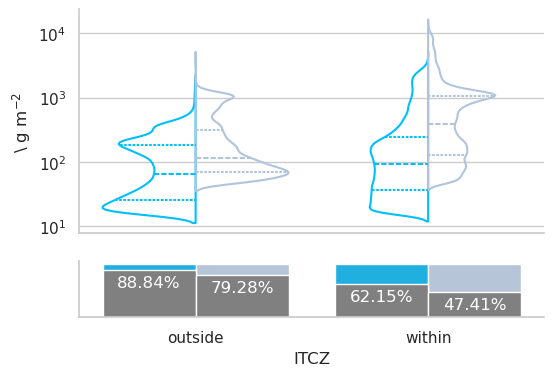

In [135]:
plt.rcParams['savefig.dpi'] = 400
fig, (ax1,ax2) = plt.subplots(2, 1, figsize=(6, 4), height_ratios=(4, 1),sharex=True)
my_pal = {'LWP':'deepskyblue','IWP':'lightsteelblue'}


#sns.boxplot(x='ITCZ', y='value', hue='variable', data=df_melted,log_scale=True,palette=my_pal,legend=False)
sns.violinplot(x='ITCZ', y='value', hue='variable', data=df_melted,log_scale=True,palette=my_pal,legend=False,split=True, inner="quart", fill=False,ax=ax1)
ax1.spines[['right', 'top']].set_visible(False)
ax1.set_xlabel('ITCZ')
ax1.set_ylabel('\\ g m$^{-2}$')

#my_pal = {'LWP':'deepskyblue','IWP':'lightsteelblue'}
grey_pal = {'LWP':'grey','IWP':'grey'}
sns.barplot(data=d,x='ITCZ',y=100,hue='variable',palette=my_pal,legend=False,ax=ax2)
sns.barplot(data=d,x='ITCZ',y='value',hue='variable',palette=grey_pal,legend=False,ax=ax2)
ax2.spines[['right', 'top',]].set_visible(False)
ax2.set( ylabel='', yticks=[])

for p,value in zip(plt.gca().patches,d['value']):
    width = p.get_width()
    height = p.get_height()
    percentage =  value
    #if not percentage.empty:
    plt.text(p.get_x() + width / 2, value-10, f"{value}%", ha="center", va="top", color='white')
plt.show()
#ax2.text()
plt.show()

Axes(0.125,0.11;0.775x0.14)


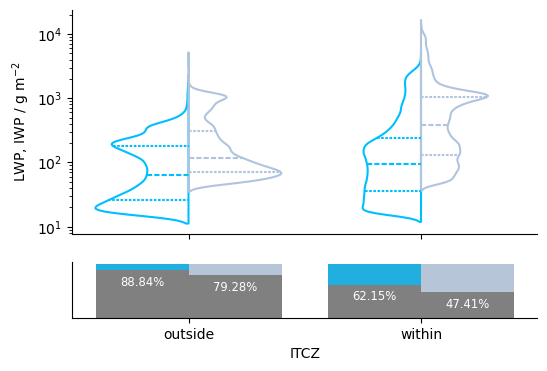

In [26]:
plot_with_percentage(sort='ITCZ', figsize=(6, 4),filename='ITCZ')#,order='ITCZ')

In [124]:
d=np.round((1-df.groupby("ITCZ").count()/df_all.groupby("ITCZ").count())*100,2)
d=d.reset_index().melt(id_vars=['ITCZ'], value_vars=[ 'LWP','IWP'])#,    
#sns.barplot(data=d,hue='ITCZ')
d

,ITCZ,variable,value
0,outside,LWP,91.53
1,within,LWP,67.72
2,outside,IWP,80.24
3,within,IWP,48.56


In [96]:
print(d)

      ITCZ variable  value
0  outside      LWP  88.84
1   within      LWP  62.15
2  outside      IWP  79.28
3   within      IWP  47.41


In [20]:
df_melted

,ITCZ,cloud type,variable,value
0,outside,NaN,LWP,NaN
1,outside,NaN,LWP,NaN
2,outside,NaN,LWP,NaN
3,outside,clear-sky,LWP,NaN
4,outside,clear-sky,LWP,NaN
...,...,...,...,...
1366187,outside,clear-sky,IWP,NaN
1366188,outside,clear-sky,IWP,NaN
1366189,outside,NaN,IWP,NaN
1366190,outside,NaN,IWP,NaN


In [57]:
df_melted.groupby('variable').count()/df_all_melted.groupby('variable').count()#.groupby("ITCZ")#.count()

,ITCZ,cloud type,value
variable,,,
IWP,1.0,1.0,0.437992
LWP,1.0,1.0,0.304887


In [47]:
d2=np.round((1-df_melted.groupby("ITCZ").count()/df_all_melted.groupby("ITCZ").count())*100,2)
d2#.pivot()

,cloud type,variable,value
ITCZ,,,
outside,0.0,0.0,78.59
within,0.0,0.0,48.57


In [26]:
#percentage of cut
d=np.round((1-df.groupby("ITCZ").count()/df_all.groupby("ITCZ").count())*100,2)
d.pivot()

,LWP,IWP,cloud type
ITCZ,,,
outside,88.84,68.34,0.0
within,62.15,34.99,0.0


In [158]:
df.groupby("ITCZ").agg(    {        "IWP": agg_list    })

IWP                                                           
          count        mean        min      median           max      skew
ITCZ                                                                      
outside   34914  271.930946  45.000458  115.436625   4063.032593  1.964639
within   232669  852.390838  45.001521  388.891418  13349.890381  3.867218

In [159]:
df_all.groupby("ITCZ").agg(    {        "IWP": agg_list    })

IWP                                                         
          count        mean       min     median           max      skew
ITCZ                                                                    
outside  168529   61.012965  0.000001   2.951899   4063.032593  4.813924
within   442402  453.175938  0.000002  56.936936  13349.890381   5.09034

### Cloud type

In [118]:
def plot_with_shading(df_all_melted=df_all_melted,df_all=df_all,sort=None,figsize=(6, 4),order=None,filename=None):
    sns.set_context("paper") #or sns.set(font_scale=2, style='ticks')
    my_pal = {'LWP':'deepskyblue','IWP':'lightsteelblue'}
    grey_pal = {'LWP':'aliceblue','IWP':'aliceblue'}
    black_pal = {'LWP':'black','IWP':'black'}
    
    d=df_all.copy()
    d['LWP']=25
    d['IWP']=50
    d=d.melt(id_vars=['ITCZ','cloud type'], value_vars=[ 'LWP','IWP'])

    ##Plotting
    plt.rcParams['savefig.dpi'] = 400
    fig, (ax) = plt.subplots(1, 1, figsize=figsize)
    
    #filling
    sns.violinplot(x=sort, y='value',  hue='variable', data=df_all_melted,log_scale=True,ax=ax,palette=my_pal,legend=False,split=True, inner="quart",order=order)
    
    #background
    sns.barplot(data=d,x=sort,y='value',hue='variable',palette=grey_pal,legend=False,ax=ax,order=order)
    #outside
    sns.violinplot(x=sort, y='value',  hue='variable', data=df_all_melted,log_scale=True,ax=ax,legend=False,split=True,palette=black_pal, inner="quart", fill=False,order=order)
    #sns.barplot(data=d,x=sort,y='value',hue='variable',palette=grey_pal,legend=False,ax=ax,order=order,alpha=0.5)
    #mean
    
    if sort:
        mean=df_all.groupby(sort).agg(    {      "LWP": ['mean'] , "IWP": ['mean']    })
    else:
        mean=df_all.agg(    {        "LWP": ['mean'] , "IWP": ['mean']     })
    mean_melted=mean.unstack().reset_index().rename(columns={('level_0'):'variable',(0):'mean'})
    kwargs={'mec':'black'}
    #sns.pointplot(data=df_all_melted,x=sort,y='value',hue='variable',legend=False,ax=ax,order=order ,dodge=True,linestyle="none",palette=my_pal,errorbar=None,**kwargs)
    sns.pointplot(data=mean_melted,x=sort,y='mean',hue='variable',legend=False,ax=ax,order=order ,dodge=True,linestyle="none",palette=my_pal,errorbar=None,**kwargs)

    #sns.pointplot(data=mean2,x='ITCZ',y='mean',hue='variable',legend=False,dodge=True,linestyle="none",palette=my_pal,errorbar=None,**kwargs)

    ax.set_ylim(top=13500)
    ax.set_yscale('symlog', linthresh=10)
    sns.set(font_scale=2, style='ticks')
      

    
    ticks = np.concat((np.arange(0,10,1),np.arange(0,100,10),np.arange(0,1000,100),np.arange(0,10000,1000)))
    ax.yaxis.set_minor_locator(ticker.FixedLocator(ticks))
    
    ax.spines[['right', 'top']].set_visible(False)
    
    

    ###plot percentages
    #if order:
    #    locs= ax.get_xticks() 
    #    labels =ax.get_xticklabels() 
    #    share= np.arange(0,len(labels))
    #    ax.set_xticklabels(f'{share+1}\n{share} %')
   # 
    
    #    d=np.round((df_all.groupby(sort).count()/df_all.count())*100,2)
     #   share=d['LWP']
      #  locs= ax.get_xticks() 
       # labels =[str(f)+'\n'+str(p) + '%' for f,p in zip(order,share)] #oder über order
        
        #ax.set_xticklabels(labels)
    
    
    plt.ylabel('LWP, IWP / g m$^{-2}$')
    
    if sort=='ITCZ':
        ax.set_xlabel('ITCZ')
    else:
        plt.xlabel('')
    plt.tight_layout()
    
    
    if filename:
        
        plt.savefig(f'/home/u/u301032/orcestra/plots/climatology_all_{sort}_{filename}.png')

    plt.show()
    

In [125]:
np.round((df_all.where(df_all['ITCZ']=='outside').groupby('cloud type').count()/df_all.where(df_all['ITCZ']=='outside').count())*100,2)

,ITCZ,IWP,LWP,cloud type
cloud type,,,,
clear-sky,50.31,53.64,53.64,NaN
deep convection,0.91,0.00,0.00,NaN
high level clouds,19.69,23.37,23.37,NaN
low level clouds,0.94,0.80,0.80,NaN
mid level clouds,0.72,0.74,0.74,NaN
upper level clouds,1.35,1.36,1.36,NaN


In [32]:
np.round((df_all.where(df_all['ITCZ']=='within').groupby('cloud type').count()/df_all.where(df_all['ITCZ']=='within').count())*100,2)

,ITCZ,IWP,LWP,cloud type
cloud type,,,,
clear-sky,29.59,29.59,29.59,NaN
deep convection,7.95,7.95,7.95,NaN
high level clouds,15.67,15.67,15.67,NaN
low level clouds,1.03,1.03,1.03,NaN
mid level clouds,1.33,1.33,1.33,NaN
upper level clouds,1.47,1.47,1.47,NaN


In [33]:
np.round((df_all.groupby('cloud type').count()/df_all.count())*100,2)

,ITCZ,IWP,LWP,cloud type
cloud type,,,,
clear-sky,36.89,36.23,36.23,NaN
deep convection,5.47,5.76,5.76,NaN
high level clouds,17.09,17.80,17.80,NaN
low level clouds,1.00,0.97,0.97,NaN
mid level clouds,1.12,1.17,1.17,NaN
upper level clouds,1.43,1.44,1.44,NaN


In [163]:
df_all.count()

LWP           683096
IWP           683096
cloud type    436019
ITCZ          683096
dtype: int64

In [162]:
df_all.groupby('cloud type').count()

,LWP,IWP,ITCZ
cloud type,,,
clear-sky,252026,252026,252026
deep convection,37037,37037,37037
high level clouds,123090,123090,123090
low level clouds,5211,5211,5211
mid level clouds,7877,7877,7877
upper level clouds,10778,10778,10778


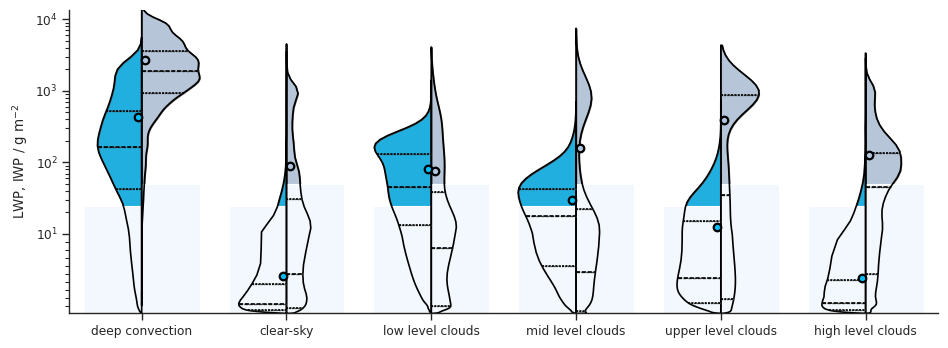

In [119]:
plot_with_shading(sort='cloud type', figsize=(10, 4),order=mask_names)#,filename='all_area_v2')

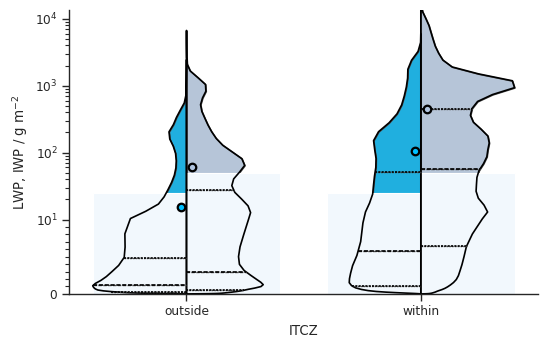

In [120]:
plot_with_shading(sort='ITCZ', figsize=(6, 4),order=['outside','within'])#,filename='v2')

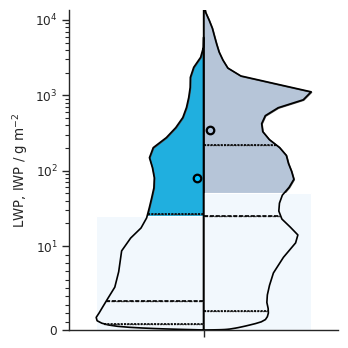

In [121]:
plot_with_shading(sort=None, figsize=(4, 4))#,filename='v2')

Axes(0.125,0.11;0.775x0.14)


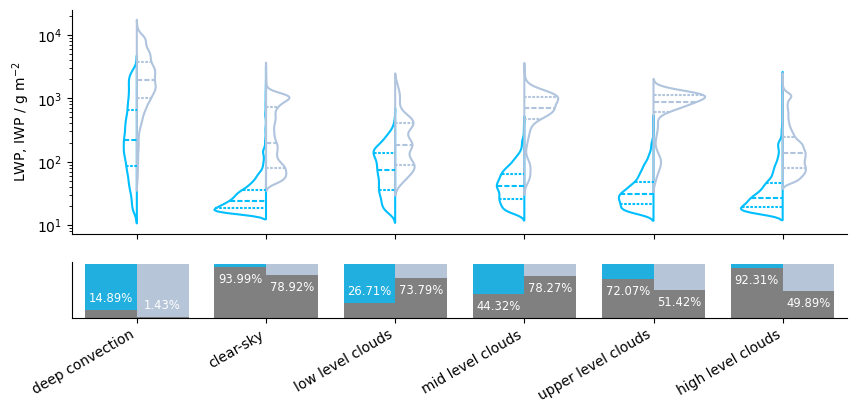

In [18]:
def plot_with_percentage(df_melted=df_melted,df=df,df_all=df_all,sort='ITCZ',figsize=(6, 4),order=None,filename=None):
    plt.rcParams['savefig.dpi'] = 400
    fig, (ax1,ax2) = plt.subplots(2, 1, figsize=figsize, height_ratios=(4, 1),sharex=True)
    my_pal = {'LWP':'deepskyblue','IWP':'lightsteelblue'}
    d=np.round((1-df.groupby(sort).count()/df_all.groupby(sort).count())*100,2)
    d=d.reset_index().melt(id_vars=[sort], value_vars=[ 'LWP','IWP'])


    #sns.boxplot(x='ITCZ', y='value', hue='variable', data=df_melted,log_scale=True,palette=my_pal,legend=False)
    sns.violinplot(x=sort, y='value', hue='variable', data=df_melted,log_scale=True,palette=my_pal,legend=False,split=True, inner="quart", fill=False,ax=ax1,order=order)
    ax1.spines[['right', 'top']].set_visible(False)
    ax1.set_xlabel(sort)
    ax1.set_ylabel('LWP, IWP / g m$^{-2}$')
    
    #my_pal = {'LWP':'deepskyblue','IWP':'lightsteelblue'}
    grey_pal = {'LWP':'grey','IWP':'grey'}
    sns.barplot(data=d,x=sort,y=100,hue='variable',palette=my_pal,legend=False,ax=ax2,order=order)
    a=sns.barplot(data=d,x=sort,y='value',hue='variable',palette=grey_pal,legend=False,ax=ax2,order=order)
    print(a)
    ax2.spines[['right', 'top']].set_visible(False)
    ax2.set( ylabel='', yticks=[])
    
    d=np.round((1-df.groupby(sort).count()/df_all.groupby(sort).count())*100,2)
    d=d.reset_index().melt(id_vars=[sort], value_vars=[ 'LWP','IWP'])
    if sort=='cloud type':
        d[sort] = pd.Categorical(d[sort], categories=mask_names, ordered=True)
        d=d.sort_values(sort)
    else:
        d=d.sort_values(sort)
        
    if sort == 'cloud type':
        plt.xticks(rotation=30,ha='right')
        plt.xlabel('')
    p_start=(int(len(plt.gca().patches)/2))

    for p in plt.gca().patches[p_start:]:
        width = p.get_width()
        height = p.get_height()
        percentage = height# value
        #if not percentage.empty:
        if height < 40:
            va= 'bottom'
            height=height+10
        else:
            va="top"
            height=height-10
        plt.text(p.get_x() + width / 2,height , f"{percentage}%", ha="center", va=va, color='white',fontsize='small')
    if filename:
        
        plt.savefig(f'/home/u/u301032/orcestra/plots/climatology_all_{filename}.png')

    plt.show()
plot_with_percentage(sort='cloud type', figsize=(10, 4),order=mask_names)#,filename='levels')

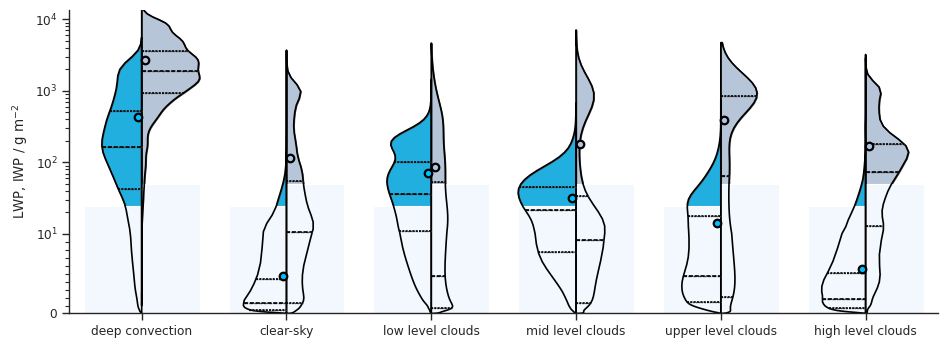

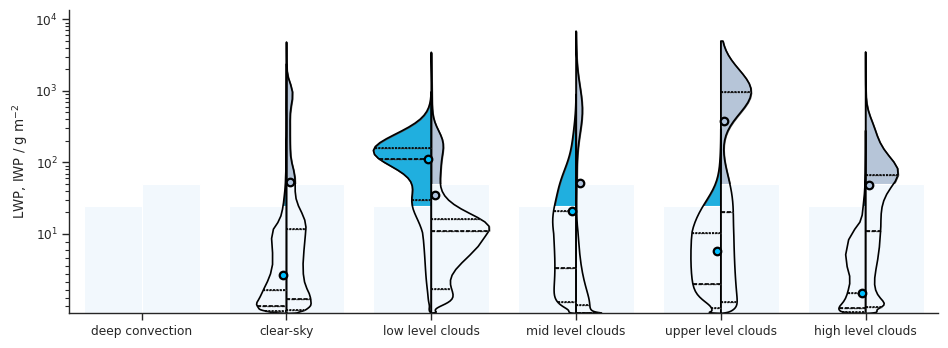

In [122]:
#inside
plot_with_shading(df_all_melted=df_all_melted.where(df_all_melted['ITCZ']=='within'),
                  df_all=df_all.where(df_all['ITCZ']=='within'),
                  sort='cloud type', figsize=(10, 4),order=mask_names)#,filename='within_v2')
#outside
plot_with_shading(df_all_melted=df_all_melted.where(df_all_melted['ITCZ']=='outside'),
                  df_all=df_all.where(df_all['ITCZ']=='outside'),
                  sort='cloud type', figsize=(10, 4),order=mask_names)#,filename='outside_v2')

In [129]:
# PERCENTAGE UNDER LIMIT

sort='cloud type'
d=np.round((1-df.where(df_all['ITCZ']=='within').groupby(sort).count()/df_all.where(df_all['ITCZ']=='within').groupby(sort).count())*100,2)
d=d.reset_index().melt(id_vars=[sort], value_vars=[ 'LWP','IWP'])
#if sort=='cloud type':
#    d[sort] = pd.Categorical(d[sort], categories=mask_names, ordered=True)
#    d.sort_values(sort)
#else:
#    d.sort_values(sort)
d

,cloud type,variable,value
0,clear-sky,LWP,96.58
1,deep convection,LWP,19.21
2,high level clouds,LWP,96.11
3,low level clouds,LWP,41.20
4,mid level clouds,LWP,55.00
5,upper level clouds,LWP,81.15
6,clear-sky,IWP,74.14
7,deep convection,IWP,1.69
8,high level clouds,IWP,42.09
9,low level clouds,IWP,74.33


In [33]:
df_all.groupby("cloud type").agg( {        "IWP": agg_list}).to_latex(float_format="{:0.1f}".format)

'\\begin{tabular}{lrlllll}\n\\toprule\n & \\multicolumn{6}{r}{IWP} \\\\\n & count & mean & min & median & max & skew \\\\\ncloud type &  &  &  &  &  &  \\\\\n\\midrule\nclear-sky & 221320 & 89.3 & 0.0 & 5.0 & 2811.6 & 3.5 \\\\\ndeep convection & 34887 & 2676.1 & 1.3 & 1879.7 & 13349.9 & 1.4 \\\\\nhigh level clouds & 114674 & 126.1 & 0.0 & 45.3 & 2056.6 & 3.1 \\\\\nlow level clouds & 4571 & 82.9 & 0.0 & 7.2 & 1591.9 & 4.2 \\\\\nmid level clouds & 7383 & 159.3 & 0.0 & 5.5 & 2396.2 & 2.2 \\\\\nupper level clouds & 9567 & 385.6 & 0.0 & 35.6 & 1451.1 & 0.7 \\\\\n\\bottomrule\n\\end{tabular}\n'

In [109]:
df_all.groupby("cloud type").describe(percentiles=[0.25, 0.75])

LWP                                   IWP            \
                       count    unique          top freq     count    unique   
cloud type                                                                     
clear-sky           221320.0  221301.0     3.716250  2.0  221320.0  221287.0   
deep convection      35191.0   35191.0  1404.813574  1.0   35191.0   35186.0   
high level clouds   108716.0  108713.0     2.261623  2.0  108716.0  108703.0   
low level clouds      5911.0    5911.0    33.218905  1.0    5911.0    5911.0   
mid level clouds      7148.0    7148.0     1.357026  1.0    7148.0    7148.0   
upper level clouds    8791.0    8791.0     0.641424  1.0    8791.0    8791.0   

                                        ITCZ                         
                            top freq   count unique     top    freq  
cloud type                                                           
clear-sky              2.911656  2.0  252026      2  within  130925  
deep convection     2503.901001  2.0   37372      2  within   35191  
high level clouds    172.094585  2.0  116719      2  within   69333  
low level clouds      24.394682  1.0    6823      2  within    4566  
mid level clouds       2.214580  1.0    7628      2  within    5902  
upper level clouds   183.148434  1.0    9752      2  within    6497

In [110]:
def percentile(n):
    def percentile_(x):
        return x.quantile(n)
    percentile_.__name__ = 'percentile_{:02.0f}'.format(n*100)
    return percentile_
percentile(25), percentile(75)


column.agg([np.sum, np.mean, np.std, np.median,
                     np.var, np.min, np.max, percentile(50), percentile(95)])
Out[11]:

In [112]:
df_all.where(df_all['ITCZ']=='within').groupby("cloud type").agg( {        "IWP": [percentile(0.50), percentile(0.95)]})

IWP              
                   percentile_50 percentile_95
cloud type                                    
clear-sky              10.524551    903.124771
deep convection      1866.845886   8097.288940
high level clouds      73.781323    888.106749
low level clouds        4.653682    463.448011
mid level clouds        9.221112   1097.839204
upper level clouds     65.253593   1208.191077

In [116]:
#inside
df_all.where(df_all['ITCZ']=='within').groupby("cloud type").agg( {        "IWP": agg_list})

IWP                                                   \
                     count        mean       min percentile_25       median   
cloud type                                                                    
clear-sky           130925  114.663002  0.000002      1.328976    10.524551   
deep convection      35191   2660.5795  1.274132    945.457680  1866.845886   
high level clouds    69333  171.142656  0.000005     13.038869    73.781323   
low level clouds      4566   86.491067  0.000291      0.697598     4.653682   
mid level clouds      5902  183.309007  0.000004      1.306930     9.221112   
upper level clouds    6497  394.494547  0.001735      2.078752    65.253593   

                                                          
                   percentile_75           max      skew  
cloud type                                                
clear-sky              54.323853   2192.801025  2.899343  
deep convection      3635.458893  13349.890381  1.422638  
high level clouds     180.874508   2056.624512  2.446293  
low level clouds       53.653483   1591.888245   3.96707  
mid level clouds       34.413714    2396.21084  2.010669  
upper level clouds    837.719727   1451.143066  0.649791

In [140]:
#outside
df_all.where(df_all['ITCZ']=='outside').groupby("cloud type").agg( {        "IWP": agg_list})
#inside
#df_all.where(df_all['ITCZ']=='within').groupby("cloud type").agg( {        "IWP": agg_list})

/home/u/u301032/.conda/envs/orcestra-retrieval-env/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1241: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


IWP                                                \
                    count        mean       min     median          max   
cloud type                                                                
clear-sky           90395   52.552435  0.000001   1.841824  2811.626709   
deep convection         0         NaN       NaN        NaN          NaN   
high level clouds   39383   48.419641  0.000008  11.076878  1819.361603   
low level clouds     1345    35.48821   0.00758  10.917028   1517.43103   
mid level clouds     1246   52.032439  0.000216   0.112212  1551.429871   
upper level clouds   2294  375.512944  0.005686  20.146769  1256.634155   

                              
                        skew  
cloud type                    
clear-sky           5.036008  
deep convection          NaN  
high level clouds   4.057675  
low level clouds    9.148167  
mid level clouds    4.347847  
upper level clouds  0.616408

In [188]:
#outside
df_all.where(df_all['ITCZ']=='outside').groupby("cloud type").agg( {        "IWP": agg_list})
#inside
#df_all.where(df_all['ITCZ']=='within').groupby("cloud type").agg( {        "IWP": agg_list})

/home/u/u301032/.conda/envs/orcestra-retrieval-env/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1241: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


IWP                                                \
                    count        mean       min     median          max   
cloud type                                                                
clear-sky           90395   52.552435  0.000001   1.841824  2811.626709   
deep convection         0         NaN       NaN        NaN          NaN   
high level clouds   40617   48.202987  0.000008  10.792698  1819.361603   
low level clouds     1089   33.991352   0.00758  10.677798   1517.43103   
mid level clouds     1255    51.65953  0.000216   0.107719  1551.429871   
upper level clouds   2490  389.649284  0.005686  23.114945  1256.634155   

                               
                         skew  
cloud type                     
clear-sky            5.036008  
deep convection           NaN  
high level clouds    4.043894  
low level clouds    10.163485  
mid level clouds     4.365642  
upper level clouds   0.558357

In [43]:
print(df_all.groupby("cloud type").agg( {        "IWP": agg_list}).to_latex(float_format="{:0.1f}".format))
df_all.groupby("cloud type").agg( {        "IWP": agg_list})

\begin{tabular}{lrlllll}
\toprule
 & \multicolumn{6}{r}{IWP} \\
 & count & mean & min & median & max & skew \\
cloud type &  &  &  &  &  &  \\
\midrule
clear-sky & 221320 & 89.3 & 0.0 & 5.0 & 2811.6 & 3.5 \\
deep convection & 35191 & 2660.6 & 1.3 & 1866.8 & 13349.9 & 1.4 \\
high level clouds & 108716 & 126.7 & 0.0 & 45.7 & 2056.6 & 3.1 \\
low level clouds & 5911 & 74.9 & 0.0 & 8.2 & 1591.9 & 4.4 \\
mid level clouds & 7148 & 160.4 & 0.0 & 5.3 & 2396.2 & 2.2 \\
upper level clouds & 8791 & 389.5 & 0.0 & 35.6 & 1451.1 & 0.6 \\
\bottomrule
\end{tabular}



IWP                                                   \
                     count        mean       min       median           max   
cloud type                                                                    
clear-sky           221320   89.294826  0.000001     4.994625   2811.626709   
deep convection      35191   2660.5795  1.274132  1866.845886  13349.890381   
high level clouds   108716  126.685534  0.000005    45.732202   2056.624512   
low level clouds      5911   74.885782  0.000291     8.242586   1591.888245   
mid level clouds      7148  160.425599  0.000004     5.251539    2396.21084   
upper level clouds    8791  389.541323  0.001735    35.605846   1451.143066   

                              
                        skew  
cloud type                    
clear-sky           3.471252  
deep convection     1.422638  
high level clouds   3.073133  
low level clouds     4.44251  
mid level clouds    2.232993  
upper level clouds   0.63967

In [44]:
## Cloud levels outside ITCZ 
print(df_all.where(df_all['ITCZ']=='outside').groupby("cloud type").agg( {        "LWP": agg_list}).to_latex(float_format="{:0.1f}".format))

\begin{tabular}{lrlllll}
\toprule
 & \multicolumn{6}{r}{LWP} \\
 & count & mean & min & median & max & skew \\
cloud type &  &  &  &  &  &  \\
\midrule
clear-sky & 90395 & 4.8 & 0.0 & 1.0 & 1677.1 & 27.3 \\
deep convection & 0 & NaN & NaN & NaN & NaN & NaN \\
high level clouds & 39383 & 2.6 & 0.0 & 0.7 & 184.2 & 7.6 \\
low level clouds & 1345 & 111.9 & 0.0 & 111.7 & 465.3 & 0.8 \\
mid level clouds & 1246 & 20.8 & 0.0 & 5.8 & 338.4 & 4.1 \\
upper level clouds & 2294 & 7.8 & 0.0 & 3.7 & 127.9 & 3.7 \\
\bottomrule
\end{tabular}



/home/u/u301032/.conda/envs/orcestra-retrieval-env/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1241: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [157]:
## Cloud levels inside ITCZ 
print(df_all.where(df_all['ITCZ']=='within').groupby("cloud type").agg( {        "LWP": agg_list}).to_latex(float_format="{:0.1f}".format))


\begin{tabular}{lrlllll}
\toprule
 & \multicolumn{6}{r}{LWP} \\
 & count & mean & min & median & max & skew \\
cloud type &  &  &  &  &  &  \\
\midrule
clear-sky & 130925 & 4.8 & 0.0 & 1.4 & 2697.3 & 71.5 \\
deep convection & 35191 & 433.0 & 0.0 & 162.0 & 3350.2 & 2.0 \\
high level clouds & 69333 & 5.6 & 0.0 & 1.8 & 2083.0 & 49.9 \\
low level clouds & 4566 & 70.9 & 0.0 & 36.7 & 822.6 & 1.8 \\
mid level clouds & 5902 & 32.2 & 0.0 & 21.3 & 410.2 & 2.7 \\
upper level clouds & 6497 & 14.1 & 0.0 & 4.7 & 424.2 & 3.8 \\
\bottomrule
\end{tabular}



In [28]:
#ITCZ 50 mm!!
df_all.where(df_all['ITCZ']=='outside').groupby("cloud type").agg( {   "LWP": agg_list,     "IWP": agg_list})

LWP                                               \
                     count       mean       min     median          max   
cloud type                                                                
clear-sky           116778   4.467922  0.000002   1.098049  1677.113159   
deep convection         13   4.048025  0.836739   3.394701     7.734103   
high level clouds    51969   3.333161       0.0   0.822947   269.345001   
low level clouds      1723  90.730095  0.007817   77.26871   450.749405   
mid level clouds      2005  23.240743  0.010397  12.677705   338.429184   
upper level clouds    3501  12.984439  0.000231   5.473763   424.161741   

                                  IWP                                       \
                         skew   count        mean         min       median   
cloud type                                                                   
clear-sky           30.504866  116778   55.549765    0.000001     2.242562   
deep convection      0.501144      13  1891.24992  865.934525  1971.124786   
high level clouds   12.803732   51969   51.177983    0.000006    13.982933   
low level clouds     0.977322    1723   27.036629    0.001095     6.156261   
mid level clouds     4.125146    2005   38.231986    0.000216     0.201217   
upper level clouds   4.838972    3501  302.146083    0.000063     6.439232   

                                            
                            max       skew  
cloud type                                  
clear-sky           2811.626709   4.841044  
deep convection     2069.960388  -3.407622  
high level clouds   1819.361603   4.281855  
low level clouds     1517.43103  11.325327  
mid level clouds    1551.429871   5.153478  
upper level clouds  1256.634155   0.961863

In [32]:
df_all.where(df_all['ITCZ']=='outside').groupby("cloud type").agg( {   "LWP": agg_list,     "IWP": agg_list})

/home/u/u301032/.conda/envs/orcestra-retrieval-env/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1241: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/u/u301032/.conda/envs/orcestra-retrieval-env/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1241: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


LWP                                                 \
                    count        mean       min      median          max   
cloud type                                                                 
clear-sky           90395    4.780388  0.000002    0.977908  1677.113159   
deep convection         0         NaN       NaN         NaN          NaN   
high level clouds   40617    2.854789       0.0    0.703741    247.25898   
low level clouds     1089  103.519548  0.007817  106.505623   332.885773   
mid level clouds     1255   20.747168  0.010397    5.849698   338.429184   
upper level clouds   2490    8.180908  0.000231    4.136832    127.86025   

                                 IWP                                   \
                         skew  count        mean       min     median   
cloud type                                                              
clear-sky           27.335479  90395   52.552435  0.000001   1.841824   
deep convection           NaN      0         NaN       NaN        NaN   
high level clouds   14.365572  40617   48.202987  0.000008  10.792698   
low level clouds     0.611205   1089   33.991352   0.00758  10.677798   
mid level clouds     4.114155   1255    51.65953  0.000216   0.107719   
upper level clouds   3.529953   2490  389.649284  0.005686  23.114945   

                                            
                            max       skew  
cloud type                                  
clear-sky           2811.626709   5.036008  
deep convection             NaN        NaN  
high level clouds   1819.361603   4.043894  
low level clouds     1517.43103  10.163485  
mid level clouds    1551.429871   4.365642  
upper level clouds  1256.634155   0.558357

In [63]:
df.groupby("cloud type").agg( {        "LWP": agg_list})


LWP                                     \
                         count        mean        min      median   
cloud type                                                          
clear-sky                13303   42.456571  15.000791   24.288407   
deep convection          29693  509.595997  15.034101  223.401154   
only high level clouds    8819   45.713111  15.001396   27.081455   
only low level clouds     3350   95.580638  15.019985   73.922725   
only mid level clouds     4111   51.951109  15.000172   40.705057   
only upper level clouds   2672   41.915244   15.00288   30.554268   

                                                 
                                 max       skew  
cloud type                                       
clear-sky                2697.259766  11.563235  
deep convection          3350.244792    1.83544  
only high level clouds   2082.968109  14.867956  
only low level clouds     506.338501   1.286224  
only mid level clouds     410.237991   2.783844  
only upper level clouds   424.161741   2.936327

In [72]:
df.groupby("cloud type").agg({        "IWP": agg_list    })

IWP                                                     \
                    count         mean        min       median           max   
cloud type                                                                     
clear-sky           46649   397.521193  45.001521   196.790136   2811.626709   
deep convection     34388  2714.526628  45.034884  1918.638895  13349.890381   
high level clouds   57458   241.049318  45.000458   134.921391   2056.624512   
low level clouds     1198   297.719708  45.070599    186.09634   1591.888245   
mid level clouds     1604   711.931014   45.23049   691.434059    2396.21084   
upper level clouds   4648    787.20822   45.04631    879.44386   1451.143066   

                              
                        skew  
cloud type                    
clear-sky           1.005464  
deep convection      1.41493  
high level clouds   2.209643  
low level clouds    2.200823  
mid level clouds    0.168917  
upper level clouds -0.708023

In [100]:
ds_radar.LWP.where(ds_radar.LWP>1).min()
df_mask_LWP.min()

all values                  1.00002
variable                        LWP
all clouds + rain          1.000551
no clouds                  1.000043
only low level clouds      1.003286
only mid level clouds      1.000238
only upper level clouds     1.00087
only high level clouds      1.00002
dtype: object

In [14]:
#for m,n in zip(mask_list,mask_name)
print('LWP')
print(df_mask_LWP.count())
print('IWP')
print(df_mask_IWP.count())

LWP
all values                 448397
variable                   683096
all clouds + rain           40643
no clouds                  149752
only low level clouds        8589
only mid level clouds       13826
only upper level clouds     11747
only high level clouds      92339
dtype: int64
IWP
all values                 466487
all clouds + rain           41208
no clouds                  157412
only low level clouds        6008
only mid level clouds       11239
only upper level clouds     12455
only high level clouds     108562
variable                   683096
dtype: int64


In [16]:
print(mask_only_low)

<xarray.DataArray 'mask_low_level_cloud' (time: 683096)> Size: 683kB
array([False, False, False, ..., False, False, False])
Coordinates:
  * time     (time) datetime64[ns] 5MB 2024-08-09T09:52:05.097473 ... 2024-09...
Attributes:
    description:  1 indicates the occurrence of radar reflectivity within 200...
    long_name:    Mask for detection of low level clouds


### influence on cloud sensitivity

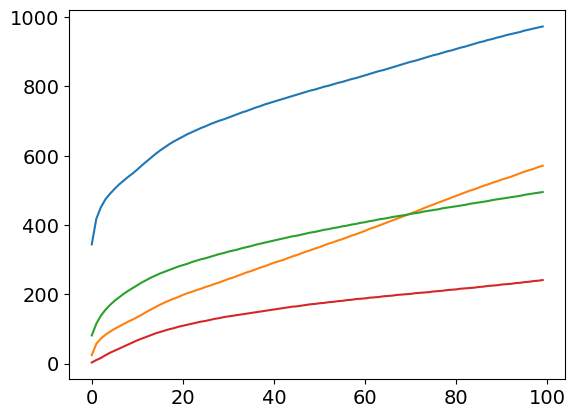

In [267]:
plt.plot(cut,I_mean)
plt.plot(cut,I_median)
plt.plot(cut,L_mean)
plt.plot(cut,L_median)

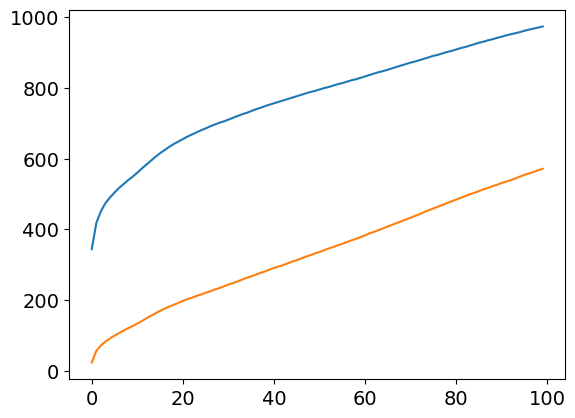

In [262]:
cut=np.arange(0,100,1)
I_mean =np.zeros_like(cut)
I_median =np.zeros_like(cut)
for i,c in enumerate(cut):
    I_mean[i]=df.IWP.where(df.IWP>c).mean()
    I_median[i]=df.IWP.where(df.IWP>c).median()
    
plt.plot(cut,I_mean)
plt.plot(cut,I_median)

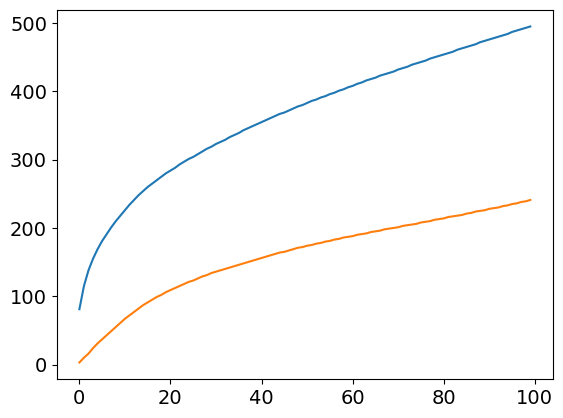

In [261]:
cut=np.arange(0,100,1)
#L_mean =np.zeros_like(cut)
L_median =np.zeros_like(cut)
for i,c in enumerate(cut):
    #L_mean[i]=df.LWP.where(df.LWP>c).mean()
    L_median[i]=df.LWP.where(df.LWP>c).median()

plt.plot(cut,L_mean)
plt.plot(cut,L_median)

In [ ]:
df_melted

In [ ]:
fig, (ax) = plt.subplots(1, 1, figsize=(6, 6))
my_pal = {'LWP':'deepskyblue','IWP':'lightsteelblue'}

#sns.boxplot( y='value',  x='variable', data=df_melted,log_scale=True,ax=ax,palette=my_pal,legend=False)
####sns.boxplot( y='value',  hue='variable', data=df_melted,log_scale=True,ax=ax,palette=my_pal,legend=False)
sns.violinplot( y='value',  x='variable', data=df_melted,log_scale=True,ax=ax,palette=my_pal,legend=False,split=True, inner="quart", fill=False)

ax.spines[['right', 'top']].set_visible(False)
plt.ylabel('\\ g m$^{-2}$')
plt.xlabel('')
plt.tight_layout()
plt.show()

## condensate loads compared with CTH

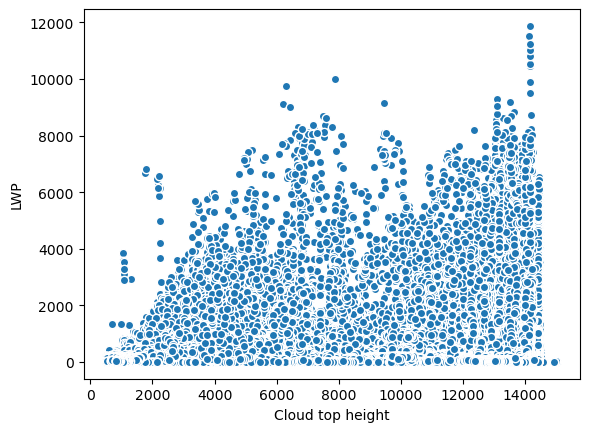

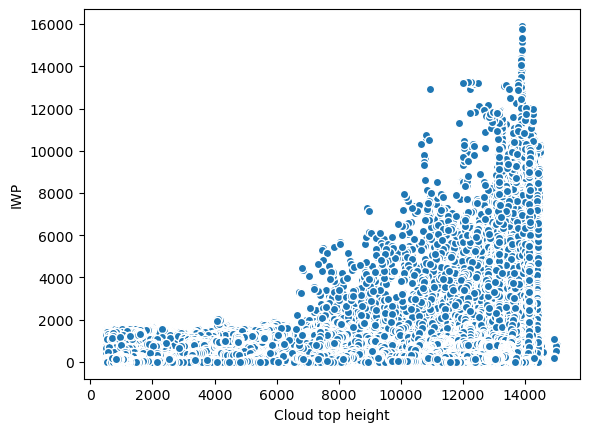

In [12]:
#fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ds_r.plot.scatter(x='CTH',y='LWP')
plt.show()
ds_r.plot.scatter(x='CTH',y='IWP')
#ds_r.CTH.plot()

#ds_r.IWP.plot()

(array([0.0000e+00, 0.0000e+00, 0.0000e+00, 1.4390e+03, 1.5460e+03,
        2.7900e+03, 3.4440e+03, 3.7700e+03, 4.0630e+03, 4.4610e+03,
        6.2790e+03, 4.7120e+03, 4.0140e+03, 3.7320e+03, 4.2100e+03,
        2.7410e+03, 3.7090e+03, 2.1150e+03, 1.5760e+03, 1.1740e+03,
        9.3800e+02, 1.0140e+03, 1.2460e+03, 9.7700e+02, 1.1080e+03,
        1.0130e+03, 1.0680e+03, 1.3700e+03, 1.3190e+03, 1.2820e+03,
        1.3640e+03, 1.3630e+03, 1.4270e+03, 1.2840e+03, 1.7680e+03,
        2.4630e+03, 2.2260e+03, 2.5400e+03, 2.0040e+03, 2.0730e+03,
        2.0760e+03, 2.6340e+03, 3.0150e+03, 1.9240e+03, 1.7440e+03,
        1.4060e+03, 1.8750e+03, 1.4960e+03, 1.4210e+03, 1.2850e+03,
        9.9200e+02, 7.6000e+02, 7.9800e+02, 9.3300e+02, 1.0430e+03,
        9.0400e+02, 8.4500e+02, 7.9500e+02, 8.2300e+02, 8.1500e+02,
        8.0800e+02, 6.9500e+02, 9.1900e+02, 7.5900e+02, 8.7500e+02,
        9.6100e+02, 9.7400e+02, 1.0350e+03, 9.5700e+02, 1.1570e+03,
        1.3610e+03, 1.5950e+03, 1.6870e+03, 1.97

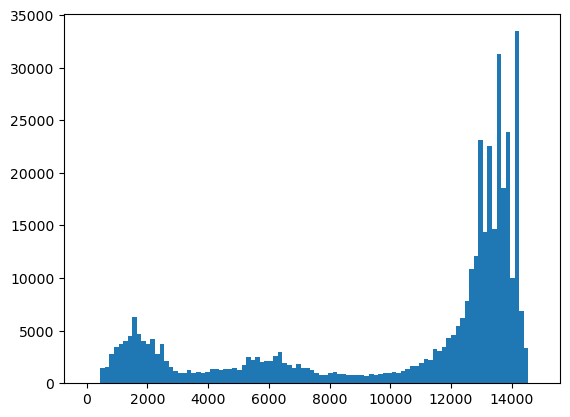

In [6]:
plt.hist(ds_radar['CTH'],bins=np.arange(0,15000,150))